<a href="https://colab.research.google.com/github/vayurenko/Netology/blob/main/%D0%94%D0%B8%D0%BF%D0%BB%D0%BE%D0%BC_%D0%BD%D0%B5%D1%82%D0%BE%D0%BB%D0%BE%D0%B3%D0%B8%D1%8F_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дипломная работа

## **Интеллектуальная система анализа и прогнозирования транспортных потоков и событий на основе методов машинного обучения в автоматизированной информационной системе «Единое парковочное пространство» в г. Москва**

Автор: Юренко Владимир Александрович

Год: 2026

---

## Как читать этот ноутбук

Ноутбук устроен как сквозное исследование: сначала я загружаю и привожу данные к единому виду, потом строю временны́е ряды, анализирую паттерны, прогнозирую нагрузку и ищу аномалии. В конце — демонстрация компьютерного зрения на отдельном кадре.

Ячейки нужно запускать **сверху вниз** — каждый следующий шаг опирается на таблицы из предыдущего.

После большинства кодовых ячеек я добавил блок **«Выводы»**: там я объясняю простыми словами, что именно показывает вывод, и какой практический смысл в этом шаге. Это не дублирование кода, а расшифровка для тех, кто смотрит ноутбук без специальной подготовки.


# Введение

Москва — один из крупнейших городов мира по числу зарегистрированных автомобилей, и управление парковочным пространством здесь давно вышло за рамки простой расстановки знаков. С 2012 года в городе работает автоматизированная система «Единое парковочное пространство» (АИС ЕПП): она фиксирует каждую платную сессию, обрабатывает оплату и формирует основу для аналитики.

Мне интересно, можно ли из этих данных извлечь что-то практически полезное: например, предсказать, когда в конкретной зоне резко вырастет спрос, или автоматически выловить часы с подозрительной активностью, которые стоит проверить вручную.

Именно это я и попытаюсь сделать в этой работе — построить исследовательский прототип системы анализа и прогнозирования транспортных потоков на данных АИС ЕПП.

---

# Объект исследования

Автоматизированная информационная система «Единое парковочное пространство» города Москвы — платформа, через которую проходят все транзакции платной парковки и данные о фиксациях транспортных средств.

---

# Предмет исследования

Методы анализа временных рядов, машинного обучения и компьютерного зрения, применённые к данным о парковочной активности: прогнозирование спроса и автоматическое выявление нетипичных периодов.

---

# Цель работы

Разработать исследовательский прототип интеллектуальной системы, которая умеет прогнозировать почасовой транспортный поток по зонам и выявлять аномальные интервалы — на данных АИС «Единое парковочное пространство».

---

# Задачи исследования

Чтобы достичь этой цели, я поставил перед собой следующие задачи:

- Изучить структуру и особенности источников данных парковочной системы.
- Провести исследовательский анализ данных (EDA).
- Построить систему признаков для моделей машинного обучения.
- Реализовать и сравнить несколько методов прогнозирования транспортных потоков.
- Разработать алгоритмы автоматического выявления аномалий.
- Оценить качество моделей и честно зафиксировать ограничения.

---


# Методология исследования

Всё исследование выполнено на Python в среде Jupyter / Google Colab.

## Стек технологий

**Язык:** Python 3.10+

**Работа с данными:** pandas, NumPy — основа любого DS-проекта, без них никуда.

**Визуализация:** Matplotlib, Seaborn — для графиков и тепловых карт.

**Машинное обучение:** scikit-learn (предобработка, метрики, Isolation Forest), LightGBM (градиентный бустинг с лагами).

**Временны́е ряды:** Prophet от Meta — умеет сам находить сезонность, удобен для быстрого прототипа.

**Нейронные сети:** TensorFlow / Keras — LSTM для прогноза последовательностей и автоэнкодер для поиска аномалий.

**Компьютерное зрение:** Ultralytics YOLOv8 — детекция объектов на дорожном кадре как демонстрация цепочки «кадр → модель → результат».


# Бизнес-цели и назначение методов

Ниже таблица, в которой я для каждого метода указал: что он показывает, какую практическую задачу решает и где он ограничен.

| Метод / модель | Что показывает | Бизнес-цель применения | Ограничение |
|---|---|---|---|
| Унификация данных сессий и фиксаций | Приводит разные источники к единому формату: зона, ГРЗ, дата, время, статус, стоимость | Получить единую базу для аналитики парковочной активности и контроля качества данных | Требуется согласованная структура выгрузок и справочников зон |
| Почасовая агрегация по зонам | Показывает, сколько парковочных сессий начинается в каждой зоне за час | Видеть нагрузку на парковочные зоны и сравнивать территории между собой | `sessions_started` отражает интенсивность спроса, но не процент занятости мест |
| EDA и календарные профили | Показывают пиковые часы, различия между буднями и выходными, зоны с высокой активностью | Планировать контроль, сопровождение и развитие парковочной инфраструктуры | Для устойчивых выводов нужна история за несколько недель или месяцев |
| Naive baseline | Показывает минимальный уровень прогноза: следующий час как предыдущий | Проверить, даёт ли сложная модель реальное улучшение относительно простого правила | Не учитывает сезонность, события и резкие изменения спроса |
| Prophet | Показывает тренд и сезонность временного ряда | Прогнозировать ожидаемую нагрузку по времени суток и дням недели | Требует достаточно длинной истории для оценки сезонности |
| LightGBM с лаговыми признаками | Показывает связь текущей нагрузки с предыдущими часами, временем суток и днём недели | Получить прикладную модель прогноза по зонам для планирования ресурсов | Нужна валидация на длинной истории и нескольких типах зон |
| LSTM | Проверяет возможность нейросетевого прогноза по последовательности значений | Оценить перспективу применения нейросетей для сложных временных зависимостей | На короткой истории может быть нестабильна и не лучше простых моделей |
| Isolation Forest | Находит интервалы, которые не похожи на обычное поведение зоны | Выделять часы, требующие дополнительной проверки диспетчером или аналитиком | Статистическая аномалия не является автоматически подтверждённым инцидентом |
| Автоэнкодер | Находит необычные сочетания признаков через ошибку восстановления | Получить второй независимый способ поиска нетипичных ситуаций | Требует аккуратной интерпретации и проверки на размеченных событиях |
| Сопоставление сессий и фиксаций МАДИ | Проверяет пересечение ГРЗ, зон и времени между двумя источниками | Контролировать согласованность данных и находить спорные кейсы фиксаций | Нужны выгрузки за один и тот же календарный период |
| Кластеризация зон | Группирует зоны с похожим суточным профилем активности | Разделять зоны на типы для разных сценариев управления и отчётности | Кластеры описывают похожесть поведения, но не объясняют причины без дополнительного анализа |
| YOLOv8 на кадре дорожной сцены | Находит на изображении транспортные объекты и людей | Показать, как из камер можно получать дополнительный признак транспортной нагрузки | Для промышленного применения нужны разрешённые видеоданные и проверка качества детекции |


# Анализ предметной области

АИС «Единое парковочное пространство» — это не просто база данных парковок. Это живая система, через которую ежедневно проходят сотни тысяч транзакций: начало и конец сессии, оплата разными способами, фиксация нарушений.

## Что делает система

- учитывает все парковочные места и ведёт статистику по зонам;
- обрабатывает оплату (мобильное приложение, SMS, банковская карта, юрлица);
- принимает данные от комплексов фото-видеофиксации (МАДИ);
- интегрируется с городскими сервисами — Яндекс, операторами связи.

## Инфраструктура

Система охватывает десятки тысяч парковочных мест по всей Москве. Данные поступают из разных источников с разной структурой — именно поэтому первый шаг в работе: привести всё к единому формату.

## Почему это интересно для анализа

Два источника данных дают разные «ракурсы» одного и того же явления: сессии показывают, когда и где паркуются люди, а фиксации МАДИ — когда нарушают. Сопоставить их — значит увидеть полную картину.


# Работа с данными и признаками

## Источники данных

Я работаю с тремя типами данных:

1. **Парковочные сессии** (`session.csv`) — каждая строка это одна парковка: зона, номер машины, время начала и конца, сумма оплаты, канал запуска (приложение, SMS и т.д.). Файл большой — больше 24 миллионов строк.

2. **Фиксации МАДИ** (папка `madi_csv/`, файлы по дням) — записи от комплексов фотофиксации: номер машины, зона, время, статус (выписан штраф или нет). За два месяца это тоже сотни тысяч строк.

3. **Демонстрационный кадр** дорожной сцены — для блока с компьютерным зрением (YOLOv8).

## Что я делаю с данными на этапе EDA

- Проверяю качество: дубликаты, пропуски, некорректные временные метки.
- Привожу идентификаторы зон к единому виду (в разных источниках они записаны по-разному).
- Агрегирую активность по часам и зонам — из миллионов строк получаю компактную таблицу временных рядов.
- Смотрю на распределения и пытаюсь понять, как «устроены» данные, прежде чем строить модели.


# Конструирование признаков

## Временны́е признаки
Самые простые, но очень важные:
- `hour` — час суток: поведение в 9 утра и в 23 вечера совсем разное;
- `dow` — день недели: будни и выходные тоже существенно отличаются;
- `ts` / `time_bucket` — часовой интервал, к которому привязана точка ряда.

## Лаговые признаки
Идея: текущее значение часто похоже на предыдущие.
- `lag_1`, `lag_2`, `lag_3` — что было час, два, три назад;
- `lag_24` — тот же час вчера (суточная сезонность);
- `lag_168` — тот же час неделю назад (если данных достаточно).

## Признаки локальной динамики
Полезны для поиска аномалий:
- `roll_mean` — скользящее среднее: какой «нормальный» уровень для этой зоны в этот период;
- `roll_std` — разброс вокруг нормы;
- `resid_ratio` — насколько текущее значение выше или ниже нормы (отношение факта к среднему).

## Пространственный признак
- `zone_id_norm` — нормализованный код зоны. Нужен для группировки и фильтрации.

Итого все признаки собираются в таблицы `ts_sessions`, `ts_madi` и `ts_merged` — по ним и работают модели.


# Прогнозирование транспортных потоков

Целевая переменная — `sessions_started`: сколько парковочных сессий начинается в конкретной зоне за один час. Это не «занятость» (для неё нужна ёмкость зоны, которой в данных нет), но хороший прокси спроса.

## Какие модели я пробую

Идем от простого к сложному:

1. **Naive baseline** — «следующий час будет как предыдущий». Задаёт нижнюю планку: если сложные модели не бьют её, значит что-то не так с данными или признаками.
2. **Prophet** — автоматически ищет тренд и сезонность. Хорош тем, что почти не требует настройки.
3. **LightGBM с лаговыми признаками** — градиентный бустинг, который учится по лагам и календарю. На практике часто работает лучше Prophet при хорошем feature engineering.
4. **LSTM** — нейросеть для последовательностей. Включил для полноты, хотя на коротких рядах обычно нестабилен.

## Как оцениваю качество

- **MAE** — средняя ошибка в тех же единицах, что ряд (начала сессий в час);
- **RMSE** — то же, но крупные промахи штрафуются сильнее;
- **MAPE** — ошибка в процентах (считаю только там, где нет нулей в ряду).

Для LightGBM использую **walk-forward validation** — обучаю на прошлом, проверяю на следующем отрезке, и так несколько раз подряд. Это честнее, чем случайное разбиение, которое «смотрит в будущее».


# Детекция аномалий

Помимо прогнозирования, было интересно понять можно ли автоматически находить часы с нетипичным поведением — те, что выбиваются из привычного паттерна зоны?

## Два подхода

**Isolation Forest** — работает с набором признаков и помечает как аномальные те точки, которые «изолировать» проще всего: они и есть статистические редкости. Настроил `contamination=0.05` — ожидаю, что около 5% точек окажутся нетипичными.

**Автоэнкодер** — нейросеть, которая учится сжимать признаки и восстанавливать их обратно. Если для какой-то точки восстановление плохое (большая ошибка), значит эта точка «не похожа» на большинство — потенциальная аномалия.

## Важная оговорка

Оба метода — не детекторы инцидентов. Они говорят «здесь что-то необычное, стоит проверить».


# Оценка качества моделей

Сравнение нескольких моделей на одной задаче — стандартная практика в DS. Я строю все модели на одном временно́м ряду по одной зоне, использую одинаковое разбиение на train/test и смотрю на одни и те же метрики. Только тогда сравнение честное.

**Ключевой принцип:** результат нужно сравнивать с baseline. Если LightGBM получает MAE=3.2, а наивная модель — MAE=3.5, это скромное улучшение на ~8%. Это нормально при коротком ряде — и важно зафиксировать честно, а не замалчивать.

## Метрики

**MAE** (средняя абсолютная ошибка) — насколько в среднем модель ошибается, в тех же единицах что ряд. Легко интерпретировать.

**RMSE** (корень из средней квадратичной ошибки) — то же, но крупные ошибки «весят» больше. Полезно, когда редкие большие промахи особенно важны.

**MAPE** (средняя абсолютная процентная ошибка) — ошибка в процентах от факта. Считаю только когда значения ряда стабильно положительные.

## Про walk-forward

Для LightGBM я использую скользящую валидацию по времени: модель несколько раз обучается на «прошлом» и проверяется на следующем окне. Это имитирует реальное применение — и даёт более честную оценку, чем случайное разбиение.

| Модель | MAE | RMSE | MAPE | Примечание |
|--------|-----|------|------|------------|
| Naive (lag=1) | — | — | — | нижняя планка |
| Seasonal naive (lag=24) | — | — | — | при достаточной длине ряда |
| Prophet | — | — | — | тренд + сезонность |
| LightGBM (walk-forward) | — | — | — | лаги + календарь |
| LSTM | — | — | — | нейросетевой прогноз |

*Числа заполняются при последовательном запуске ячеек прогнозирования.*


## Подготовка окружения

Перед стартом нужно убедиться, что все библиотеки установлены и работают. Здесь же определяется функция `ensure_tensorflow_import`, которую я вызываю позже, уже непосредственно перед ячейками с нейросетями — чтобы не тормозить запуск всего ноутбука ради TF.


In [28]:
# Подготовка окружения
# Если возникает ошибка совместимости NumPy 1.x / 2.x:
#   pip install "numpy>=1.26,<2"  и перезапустите ядро (Kernel → Restart).

import importlib
import importlib.util
import os
import subprocess
import sys
import warnings


def ensure_tensorflow_import() -> None:
    """Пытается импортировать TensorFlow; при сбое — ставит tensorflow==2.16.2 + protobuf 4.x.

    Если после ячейки ошибка остаётся — сделайте Kernel → Restart и снова запустите эту ячейку.
    """

    def _pip(*args: str) -> None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

    def _purge_tf_stack() -> None:
        dead = [
            k for k in list(sys.modules)
            if "tensorflow" in k
            or k.startswith("google.protobuf")
            or k in ("keras",)
            or k.startswith("keras.")
        ]
        for k in dead:
            sys.modules.pop(k, None)

    def _try_tf():
        try:
            import tensorflow as _tf  # noqa: F401
            return True, ""
        except BaseException as e:
            return False, f"{type(e).__name__}: {e}"

    ok, err = _try_tf()
    if ok:
        return

    print("TensorFlow не импортируется — откатываю к tensorflow==2.16.2 + protobuf 4.x ...")
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-y",
         "protobuf", "tensorflow", "tensorflow-cpu", "tensorflow-intel"],
        capture_output=True, text=True,
    )
    _pip("protobuf>=4.25.3,<5", "tensorflow==2.16.2")
    _purge_tf_stack()
    importlib.invalidate_caches()

    ok, err = _try_tf()
    if ok:
        import tensorflow as _tf
        print("TensorFlow OK, версия:", getattr(_tf, "__version__", "?"))
        return

    raise ImportError(
        "TensorFlow не удалось импортировать после переустановки. "
        "Сделайте Kernel → Restart, затем снова «Подготовка окружения». "
        "Техническая ошибка: " + err[:500]
    )




def _is_colab() -> bool:
    """Автоопределяем запуск в Google Colab."""
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


# Если пользователь не задал COLAB_MEMORY_SAFE_MODE явно — автоопределяем
if "COLAB_MEMORY_SAFE_MODE" not in globals():
    COLAB_MEMORY_SAFE_MODE = _is_colab()

if COLAB_MEMORY_SAFE_MODE:
    print(
        "Включён режим экономии памяти для Google Colab: будут применены лимиты "
        "на объём чтения session.csv, файлов МАДИ и нейросетевых блоков. "
        "Для отключения задайте COLAB_MEMORY_SAFE_MODE=0."
    )

# Отключаю предупреждения — они не несут смысловой нагрузки в контексте диплома
warnings.filterwarnings("ignore")
print("Окружение готово. TF подключится позже — только в ячейках LSTM и автоэнкодера.")


Включён режим экономии памяти для Google Colab: будут применены лимиты на объём чтения session.csv, файлов МАДИ и нейросетевых блоков. Для отключения задайте COLAB_MEMORY_SAFE_MODE=0.
Окружение готово. TF подключится позже — только в ячейках LSTM и автоэнкодера.


## Загрузка датасета

Два основных источника:
- `session.csv` — парковочные сессии (разделитель `;`);
- каталог `madi_csv/` с ежедневными файлами фиксаций МАДИ.

На следующих шагах оба источника приводятся к единому формату и объединяются по зоне и времени.


In [29]:
# Определяю путь к данным: в Colab — Google Drive, локально — папка через env. Локально можно обработать бОльшие массивы.
import os

try:
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    DATA_DIR = "/content/drive/MyDrive/Проект_Нетология"
except ImportError:
    # Локально: export DIPLOM_DATA_DIR=/полный/путь/к/папке/с/csv
    _cand = [
        os.environ.get("DIPLOM_DATA_DIR"),
        os.path.join(os.path.expanduser("~"), "Desktop", "Нетология"),
    ]
    DATA_DIR = next((p for p in _cand if p and os.path.isdir(p)), None)
    if DATA_DIR is None:
        raise RuntimeError(
            "Задайте папку с данными: переменная окружения DIPLOM_DATA_DIR "
            "(должны лежать session.csv и каталог madi_csv/ или madi.csv)"
        )

assert os.path.isdir(DATA_DIR), f"Папка не найдена: {DATA_DIR}"
print("DATA_DIR:", DATA_DIR)
print("Файлы в проекте:", os.listdir(DATA_DIR))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR: /content/drive/MyDrive/Проект_Нетология
Файлы в проекте: ['session_sample.csv', 'session.csv', 'madi_csv']


## Загрузка данных и первичный осмотр

Загружаю оба источника и смотрю на их типы столбцов и пропуски. Это стандартный первый шаг — нельзя доверять данным вслепую.

Форматы данных:
- `session.csv` — разделитель `;`, временны́е метки в миллисекундах Unix-времени;
- файлы МАДИ — CSV с заголовком `id,vrp,date,zoneNumber,action` или устаревший TSV без заголовка.

В Google Colab включается режим экономии памяти `COLAB_MEMORY_SAFE_MODE` — он ограничивает число читаемых строк, чтобы не переполнить RAM. Логика расчётов от этого не меняется.


In [30]:
import gc
import glob
import importlib.util
import os
from typing import Optional

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:

    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        elif hasattr(obj, "head"):
            print(obj.head(15).to_string())
        else:
            print(obj)

SESSION_FILE = os.environ.get("SESSION_FILE", "session.csv")
session_path = os.path.join(DATA_DIR, SESSION_FILE)
assert os.path.isfile(session_path), f"Нет файла сессий: {session_path}"

# В Colab включается безопасный режим: не читаем полный 2+ GB session.csv и все MADI-файлы целиком.
def _is_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

_colab_safe = bool(globals().get("COLAB_MEMORY_SAFE_MODE", _is_colab()))
_default_session_nrows = 750_000 if _colab_safe else 0
_default_madi_nrows = 200_000 if _colab_safe else 0
SESSION_NROWS = int(os.environ.get("SESSION_NROWS", str(_default_session_nrows)))
MADI_NROWS_PER_FILE = int(os.environ.get("MADI_NROWS_PER_FILE", str(_default_madi_nrows)))

print("Файлы в каталоге:", os.listdir(DATA_DIR))
print("COLAB_MEMORY_SAFE_MODE:", _colab_safe)
print("SESSION_NROWS:", "без лимита" if SESSION_NROWS == 0 else SESSION_NROWS)
print("MADI_NROWS_PER_FILE:", "без лимита" if MADI_NROWS_PER_FILE == 0 else MADI_NROWS_PER_FILE)

_pyarrow_available = importlib.util.find_spec("pyarrow") is not None
_default_csv_engine = "pyarrow" if (not _colab_safe and _pyarrow_available) else "c"
CSV_ENGINE = os.environ.get("DIPLOM_CSV_ENGINE", _default_csv_engine).strip().lower()
if CSV_ENGINE not in {"c", "pyarrow"}:
    CSV_ENGINE = "c"
print("CSV engine:", CSV_ENGINE, "(pyarrow available:", _pyarrow_available, ")")


def _read_csv_optimized(path: str, *, sep: str = ",", nrows: Optional[int] = None, **kwargs) -> pd.DataFrame:
    read_nrows = None if nrows in (None, 0) else int(nrows)
    use_pyarrow = CSV_ENGINE == "pyarrow" and read_nrows is None
    if use_pyarrow:
        try:
            return pd.read_csv(path, sep=sep, engine="pyarrow", **kwargs)
        except Exception as e:
            print(f"pyarrow engine не сработал для {os.path.basename(path)} ({type(e).__name__}); fallback на engine='c'.")
    return pd.read_csv(path, sep=sep, low_memory=False, nrows=read_nrows, **kwargs)


def load_sessions_csv(path: str, nrows: Optional[int] = None) -> pd.DataFrame:
    df = _read_csv_optimized(path, sep=";", nrows=nrows)
    last_col = df.columns[-1]
    df = df.rename(columns={last_col: "SESSION_COST"})
    return df


def unify_sessions(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.rename(
        columns={
            "ID": "session_id",
            "ZONENUMBER": "zone_id",
            "VRP_RU": "plate",
            "ACCOUNTID": "user_id",
            "START_TIME": "start_ts_ms",
            "END_TIME": "end_ts_ms",
            "METHOD_": "payment_method",
            "SAP_INITIATIONSOURCE": "source",
            "GPS": "gps_raw",
        }
    )
    out["zone_id"] = out["zone_id"].astype(str).str.strip()
    out["plate"] = out["plate"].astype(str).str.strip()
    out["plate"] = out["plate"].replace({"": np.nan, "nan": np.nan, "None": np.nan})
    for c in ["start_ts_ms", "end_ts_ms"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    out["start_datetime"] = pd.to_datetime(out["start_ts_ms"], unit="ms", errors="coerce")
    out["end_datetime"] = pd.to_datetime(out["end_ts_ms"], unit="ms", errors="coerce")
    out["start_date"] = out["start_datetime"].dt.date
    out["start_time"] = out["start_datetime"].dt.time
    out["end_date"] = out["end_datetime"].dt.date
    out["end_time"] = out["end_datetime"].dt.time
    if "gps_raw" in out.columns:
        gps = out["gps_raw"].astype(str)
        spl = gps.str.split(",", n=1, expand=True)
        out["lat"] = pd.to_numeric(spl[0], errors="coerce")
        out["lon"] = pd.to_numeric(spl[1], errors="coerce") if spl.shape[1] > 1 else np.nan
    else:
        out["lat"] = np.nan
        out["lon"] = np.nan
    out["SESSION_COST"] = pd.to_numeric(out["SESSION_COST"], errors="coerce")
    cols_order = [
        "session_id",
        "zone_id",
        "plate",
        "user_id",
        "start_datetime",
        "end_datetime",
        "start_date",
        "start_time",
        "end_date",
        "end_time",
        "payment_method",
        "source",
        "SESSION_COST",
        "lat",
        "lon",
        "gps_raw",
        "start_ts_ms",
        "end_ts_ms",
    ]
    cols_order = [c for c in cols_order if c in out.columns]
    return out[cols_order]


def load_madi_export_csv(path: str, nrows: Optional[int]) -> pd.DataFrame:
    """Выгрузка МАДИ: CSV с заголовком id,vrp,date,zoneNumber,action."""
    df = _read_csv_optimized(path, nrows=nrows)
    df.columns = [str(c).strip().lower() for c in df.columns]
    cmap = {
        "id": "fixation_id",
        "vrp": "plate",
        "date": "fixation_ts_ms",
        "zonenumber": "zone_id",
        "action": "status",
    }
    miss = set(cmap.keys()) - set(df.columns)
    if miss:
        raise ValueError(f"{path}: не хватает колонок {miss}, есть {list(df.columns)}")
    df = df.rename(columns=cmap)
    df["fixation_id"] = pd.to_numeric(df["fixation_id"], errors="coerce").astype("Int64")
    return df


def load_madi_legacy_tsv(path: str, nrows: Optional[int]) -> pd.DataFrame:
    """Старый формат: TSV без заголовка."""
    return _read_csv_optimized(
        path,
        sep="\t",
        nrows=nrows,
        header=None,
        names=["fixation_id", "plate", "fixation_ts_ms", "zone_id", "status"],
        dtype={"fixation_id": "Int64"},
    )


def resolve_madi_raw(data_dir: str, nrows_per_file: int) -> pd.DataFrame:
    """Собирает МАДИ из madi_csv/result_*.csv, одиночного madi.csv или legacy TSV."""
    madi_dir = os.path.join(data_dir, "madi_csv")
    single_csv = os.path.join(data_dir, "madi.csv")
    legacy_tsv = os.path.join(data_dir, "madi.tsv")

    nr = None if nrows_per_file == 0 else nrows_per_file
    frames: list[pd.DataFrame] = []

    if os.path.isdir(madi_dir):
        paths = sorted(glob.glob(os.path.join(madi_dir, "result_*.csv")))
        if not paths:
            raise FileNotFoundError(f"В {madi_dir} нет result_*.csv")
        for p in paths:
            frames.append(load_madi_export_csv(p, nr))
            print(f"  МАДИ: {os.path.basename(p)} -> {len(frames[-1])} строк")
    elif os.path.isfile(single_csv):
        frames.append(load_madi_export_csv(single_csv, nr))
        print(f"  МАДИ: madi.csv -> {len(frames[0])} строк")
    elif os.path.isfile(legacy_tsv):
        frames.append(load_madi_legacy_tsv(legacy_tsv, nr))
        print(f"  МАДИ: legacy madi.tsv -> {len(frames[0])} строк")
    else:
        raise FileNotFoundError(
            f"Не найдены данные МАДИ: ожидался каталог {madi_dir} или файл {single_csv}"
        )

    out = pd.concat(frames, ignore_index=True)
    before = len(out)
    out = out.drop_duplicates(subset=["fixation_id"], keep="last")
    print(f"МАДИ: всего строк после concat: {before}, после dedup по fixation_id: {len(out)}")
    return out


def unify_madi(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["zone_id"] = out["zone_id"].astype(str).str.strip()
    out["plate"] = out["plate"].astype(str).str.strip()
    out["fixation_ts_ms"] = pd.to_numeric(out["fixation_ts_ms"], errors="coerce")
    out["fixation_datetime"] = pd.to_datetime(out["fixation_ts_ms"], unit="ms", errors="coerce")
    out["fixation_date"] = out["fixation_datetime"].dt.date
    out["fixation_time"] = out["fixation_datetime"].dt.time
    out["status"] = pd.to_numeric(out["status"], errors="coerce").astype("Int64")
    cols_order = [
        "fixation_id",
        "fixation_datetime",
        "fixation_date",
        "fixation_time",
        "zone_id",
        "plate",
        "status",
        "fixation_ts_ms",
    ]
    return out[cols_order]


df_sess_raw = load_sessions_csv(session_path, SESSION_NROWS)
df_madi_raw = resolve_madi_raw(DATA_DIR, MADI_NROWS_PER_FILE)
df_sessions_unified = unify_sessions(df_sess_raw)
df_madi_unified = unify_madi(df_madi_raw)

# Сырые таблицы больше не нужны; освобождаем память перед моделированием.
del df_sess_raw, df_madi_raw
gc.collect()


def short_report(name: str, df: pd.DataFrame) -> None:
    print("=" * 72)
    print(name)
    print("=" * 72)
    print("shape:", df.shape)
    print("\ndtypes:\n", df.dtypes)
    print("\nПропуски (%):\n", (df.isna().mean() * 100).round(2).sort_values(ascending=False).head(20))
    display(df.head(3))


short_report("df_sessions_unified", df_sessions_unified)
short_report("df_madi_unified", df_madi_unified)


Файлы в каталоге: ['session_sample.csv', 'session.csv', 'madi_csv']
COLAB_MEMORY_SAFE_MODE: True
SESSION_NROWS: 750000
MADI_NROWS_PER_FILE: 200000
CSV engine: c (pyarrow available: True )
  МАДИ: result_2026-01-06.csv -> 200000 строк
  МАДИ: result_2026-01-08.csv -> 200000 строк
  МАДИ: result_2026-01-10.csv -> 200000 строк
  МАДИ: result_2026-01-27.csv -> 200000 строк
  МАДИ: result_2026-01-31.csv -> 200000 строк
  МАДИ: result_2026-02-06.csv -> 200000 строк
  МАДИ: result_2026-02-10.csv -> 200000 строк
  МАДИ: result_2026-02-18.csv -> 200000 строк
  МАДИ: result_2026-02-24.csv -> 200000 строк
  МАДИ: result_2026-02-25.csv -> 200000 строк
  МАДИ: result_2026-02-26.csv -> 200000 строк
  МАДИ: result_2026-02-27.csv -> 200000 строк
  МАДИ: result_2026-02-28.csv -> 200000 строк
  МАДИ: result_2026-03-04.csv -> 200000 строк
  МАДИ: result_2026-03-06.csv -> 200000 строк
  МАДИ: result_2026-03-07.csv -> 200000 строк
  МАДИ: result_2026-03-08.csv -> 200000 строк
  МАДИ: result_2026-03-09.csv 

,session_id,zone_id,plate,user_id,start_datetime,end_datetime,start_date,start_time,end_date,end_time,payment_method,source,SESSION_COST,lat,lon,gps_raw,start_ts_ms,end_ts_ms
0,1310526601,8302,М752ОХ799,1251076,2026-02-12 17:27:49.026,2026-02-12 18:30:49.026,2026-02-12,17:27:49.026000,2026-02-12,18:30:49.026000,NaN,iosMobileApp,309.0,NaN,NaN,NaN,1770917269026,1770921049026
1,1336764889,0305,У130КН977,1651754,2026-03-24 10:51:00.000,2026-03-24 11:51:00.000,2026-03-24,10:51:00,2026-03-24,11:51:00,NaN,iosMobileApp,380.0,55.778149,37.640431,"55.7781485430016,37.6404308246484",1774349460000,1774353060000
2,1300389049,70023,С956УР797,8186103,2026-01-27 18:29:14.874,2026-01-27 18:33:14.874,2026-01-27,18:29:14.874000,2026-01-27,18:33:14.874000,NaN,androidMobileApp,4.0,55.738737,37.524972,"55.7387367,37.5249717",1769538554874,1769538794874


df_madi_unified
shape: (5000000, 8)

dtypes:
 fixation_id                   Int64
fixation_datetime    datetime64[ns]
fixation_date                object
fixation_time                object
zone_id                      object
plate                        object
status                        Int64
fixation_ts_ms                int64
dtype: object

Пропуски (%):
 fixation_id          0.0
fixation_datetime    0.0
fixation_date        0.0
fixation_time        0.0
zone_id              0.0
plate                0.0
status               0.0
fixation_ts_ms       0.0
dtype: float64


,fixation_id,fixation_datetime,fixation_date,fixation_time,zone_id,plate,status,fixation_ts_ms
0,7072622138,2026-01-04 12:00:05,2026-01-04,12:00:05,4059,Т310МР71,0,1767528005000
1,7070154293,2026-01-03 23:48:26,2026-01-03,23:48:26,4066,Н093СВ799,0,1767484106000
2,7072514825,2026-01-04 11:38:57,2026-01-04,11:38:57,4022,Т409СВ199,0,1767526737000


#### Что здесь видим

1. **Список файлов** — ноутбук нашёл нужные файлы.
2. **`COLAB_MEMORY_SAFE_MODE`** — если `True`, данные читаются частично из-за ограничения ресурсов Colab.
3. **Таблицы после унификации** — приводим поля к понятным именам: время, зона, номер машины, стоимость. Пропуски в `payment_method` и `gps_raw` — нормально, многие сессии запускаются без GPS.


### Нормализация кодов зон

Нашел, что один и тот же номер зоны в разных источниках записан по-разному. В сессиях зона 302 может быть `302`, в МАДИ — `0302`. Если оставить как есть, при объединении таблиц потеряется много записей.

Для исправления дополняем все коды нулями вначале до одинаковой длины. Например `302` и `0302` превращаются в `00302`.


In [31]:
import numpy as np

from typing import Optional


def normalize_zone_id(series: pd.Series, width: Optional[int] = None) -> pd.Series:
    s = series.astype(str).str.strip()
    s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    if width is None:
        # выравниваем длину по самому длинному коду среди непустых
        non_null = s.dropna()
        w = int(non_null.str.len().max()) if len(non_null) else 4
        width = max(w, 4)
    return s.str.zfill(width)


# Автоматическая ширина зоны по объединённым данным
_all_zones = pd.concat(
    [df_sessions_unified["zone_id"], df_madi_unified["zone_id"]],
    ignore_index=True,
).astype(str).str.strip()
_zone_width = int(_all_zones.str.len().max())
_zone_width = max(_zone_width, 4)

df_sessions_unified["zone_id_norm"] = normalize_zone_id(df_sessions_unified["zone_id"], width=_zone_width)
df_madi_unified["zone_id_norm"] = normalize_zone_id(df_madi_unified["zone_id"], width=_zone_width)

# Производные по сессии
df_sessions_unified["duration_min"] = (
    (df_sessions_unified["end_datetime"] - df_sessions_unified["start_datetime"]).dt.total_seconds() / 60.0
)

df_sessions_unified["start_hour"] = df_sessions_unified["start_datetime"].dt.hour
df_sessions_unified["start_dow"] = df_sessions_unified["start_datetime"].dt.dayofweek  # 0=Пн

bad_duration = (df_sessions_unified["duration_min"] <= 0) | (df_sessions_unified["duration_min"].isna())
n_bad = int(bad_duration.sum())
if n_bad:
    print(f"Внимание: строк с некорректной длительностью: {n_bad} (можно отфильтровать позже)")
    # df_sessions_unified = df_sessions_unified.loc[~bad_duration].copy()

# Пересечение зон между источниками
zones_sess = set(df_sessions_unified["zone_id_norm"].dropna().unique())
zones_madi = set(df_madi_unified["zone_id_norm"].dropna().unique())
zones_both = zones_sess & zones_madi

print("Ширина нормализации zone_id (символов):", _zone_width)
print("Уникальных зон (сессии):", len(zones_sess))
print("Уникальных зон (МАДИ):", len(zones_madi))
print("Зон в пересечении:", len(zones_both))

# Короткая сводка пропусков по ключевым полям сессий
key_cols = ["payment_method", "gps_raw", "lat", "lon"]
miss = (df_sessions_unified[key_cols].isna().mean() * 100).round(2)
print("\nПропуски по сессиям (%):\n", miss)

display(df_sessions_unified[["session_id", "zone_id", "zone_id_norm", "start_datetime", "duration_min", "start_hour", "start_dow"]].head(5))
display(df_madi_unified.head(5))

Ширина нормализации zone_id (символов): 5
Уникальных зон (сессии): 1301
Уникальных зон (МАДИ): 419
Зон в пересечении: 404

Пропуски по сессиям (%):
 payment_method    72.44
gps_raw           38.07
lat               38.07
lon               38.07
dtype: float64


,session_id,zone_id,zone_id_norm,start_datetime,duration_min,start_hour,start_dow
0,1310526601,8302,08302,2026-02-12 17:27:49.026,63.0,17,3
1,1336764889,0305,00305,2026-03-24 10:51:00.000,60.0,10,1
2,1300389049,70023,70023,2026-01-27 18:29:14.874,4.0,18,1
3,1341713942,4015,04015,2026-03-31 07:23:00.000,115.0,7,1
4,1309451634,0314,00314,2026-02-11 11:25:10.684,97.0,11,2


,fixation_id,fixation_datetime,fixation_date,fixation_time,zone_id,plate,status,fixation_ts_ms,zone_id_norm
0,7072622138,2026-01-04 12:00:05,2026-01-04,12:00:05,4059,Т310МР71,0,1767528005000,04059
1,7070154293,2026-01-03 23:48:26,2026-01-03,23:48:26,4066,Н093СВ799,0,1767484106000,04066
2,7072514825,2026-01-04 11:38:57,2026-01-04,11:38:57,4022,Т409СВ199,0,1767526737000,04022
3,7072178596,2026-01-04 10:25:39,2026-01-04,10:25:39,301,А788НТ199,0,1767522339000,00301
4,7071841497,2026-01-04 08:52:39,2026-01-04,08:52:39,70029,Н965МУ797,0,1767516759000,70029


Теперь идентификаторы зон во всех таблицах выглядят одинаково. Число зон в пересечении двух источников показывает, сколько зон можно будет сопоставить при  анализе. Если пересечение маленькое — скорее всего, данные за разные периоды (об этом явно говорит следующий шаг).


### Сопоставление сессий и фиксаций МАДИ

Пробуем найти ситуации, когда машина стояла на парковке (есть сессия) и одновременно была зафиксирована камерой МАДИ (есть запись о фиксации). Сопоставление идёт по трём условиям: одинаковый нормализованный номер (ГРЗ), одинаковая зона, и время фиксации попадает внутрь интервала сессии.

Это «строгий» сценарий. Если данные за разные периоды — результат будет пустым или маленьким.


In [32]:
import os
from datetime import datetime
from typing import Optional

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)


MADI_NO_FINE_STATUSES = {0, 1}
MADI_FINE_CANDIDATE_STATUS = 2
MADI_ALREADY_FINE_STATUS = 3
MADI_DAILY_FINE_STATUSES = {MADI_FINE_CANDIDATE_STATUS, MADI_ALREADY_FINE_STATUS}


def _norm_plate(s: pd.Series) -> pd.Series:
    x = s.astype(str).str.strip().str.upper()
    x = x.replace({"": np.nan, "NAN": np.nan, "NONE": np.nan})
    return x


def _parse_date(s: Optional[str]) -> Optional[datetime]:
    if not s:
        return None
    s = str(s).strip()
    for fmt in ("%Y-%m-%d", "%d.%m.%Y"):
        try:
            return datetime.strptime(s, fmt)
        except ValueError:
            continue
    return None


def _madi_status_label(status: object) -> str:
    if pd.isna(status):
        return "статус не определён"
    status_int = int(status)
    if status_int in MADI_NO_FINE_STATUSES:
        return "без штрафа"
    if status_int == MADI_FINE_CANDIDATE_STATUS:
        return "кандидат на штраф"
    if status_int == MADI_ALREADY_FINE_STATUS:
        return "штраф ранее выставлен"
    return "прочий статус"


def _add_madi_status_flags(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["status_int"] = pd.to_numeric(out["status"], errors="coerce").astype("Int64")
    out["status_label"] = out["status_int"].map(_madi_status_label)
    out["no_fine"] = out["status_int"].isin(MADI_NO_FINE_STATUSES)
    out["fine_candidate"] = out["status_int"].eq(MADI_FINE_CANDIDATE_STATUS)
    out["already_fined"] = out["status_int"].eq(MADI_ALREADY_FINE_STATUS)
    out["daily_fine_event"] = out["status_int"].isin(MADI_DAILY_FINE_STATUSES)
    return out


d0s = os.environ.get("DIPLOM_MATCH_DATE_START")
d1s = os.environ.get("DIPLOM_MATCH_DATE_END")
d0 = _parse_date(d0s)
d1 = _parse_date(d1s)

if d0 is None or d1 is None:
    smin = pd.Timestamp(df_sessions_unified["start_datetime"].min()).normalize()
    smax = pd.Timestamp(df_sessions_unified["start_datetime"].max()).normalize()
    mmin = pd.Timestamp(df_madi_unified["fixation_datetime"].min()).normalize()
    mmax = pd.Timestamp(df_madi_unified["fixation_datetime"].max()).normalize()
    ov0, ov1 = max(smin, mmin), min(smax, mmax)
    if ov0 <= ov1:
        d0, d1 = ov0.to_pydatetime(), ov1.to_pydatetime()
        print("DIPLOM_MATCH_DATE_* не заданы — используется пересечение календарей:", d0.date(), "—", d1.date())
    else:
        d0, d1 = mmin.to_pydatetime(), mmax.to_pydatetime()
        print("DIPLOM_MATCH_DATE_* не заданы, пересечения нет — берём окно по МАДИ:", d0.date(), "—", d1.date())
else:
    if d0 > d1:
        d0, d1 = d1, d0
    print("Окно сопоставления (из env):", d0.date(), "—", d1.date())

d0d, d1d = d0.date(), d1.date()

sess = df_sessions_unified.copy()
sess["plate_norm"] = _norm_plate(sess["plate"])
sess = sess.dropna(subset=["plate_norm", "zone_id_norm", "start_datetime", "end_datetime"])

madi = df_madi_unified.copy()
madi["plate_norm"] = _norm_plate(madi["plate"])
madi = madi.dropna(subset=["plate_norm", "zone_id_norm", "fixation_datetime"])
madi = _add_madi_status_flags(madi)
madi["fixation_day"] = madi["fixation_datetime"].dt.date

m_win = (madi["fixation_day"] >= d0d) & (madi["fixation_day"] <= d1d)
madi_w = madi.loc[m_win].copy()

# Проверка бизнес-правила: не более одного штрафного события по ГРЗ в день.
daily_fines = madi_w.loc[madi_w["daily_fine_event"]].copy()
if len(daily_fines):
    daily_counts = (
        daily_fines.groupby(["plate_norm", "fixation_day"], as_index=False)
        .agg(
            daily_fine_events=("fixation_id", "count"),
            statuses=("status_int", lambda s: ",".join(map(str, sorted(set(s.dropna().astype(int)))))),
            first_fixation=("fixation_datetime", "min"),
            last_fixation=("fixation_datetime", "max"),
        )
    )
    violation_keys = daily_counts.loc[daily_counts["daily_fine_events"] > 1]
    MADI_DAILY_FINE_VIOLATIONS = daily_fines.merge(
        violation_keys[["plate_norm", "fixation_day", "daily_fine_events", "statuses"]],
        on=["plate_norm", "fixation_day"],
        how="inner",
    ).sort_values(["plate_norm", "fixation_day", "fixation_datetime"])
else:
    violation_keys = pd.DataFrame(columns=["plate_norm", "fixation_day", "daily_fine_events", "statuses"])
    MADI_DAILY_FINE_VIOLATIONS = pd.DataFrame()

print("Статусы МАДИ в окне:")
display(madi_w["status_label"].value_counts(dropna=False).to_frame("число фиксаций"))
print("ГРЗ-дней с более чем одним штрафным событием (статусы 2/3):", len(violation_keys))
if len(MADI_DAILY_FINE_VIOLATIONS):
    display(
        MADI_DAILY_FINE_VIOLATIONS[
            [
                "fixation_id",
                "fixation_datetime",
                "fixation_day",
                "plate_norm",
                "zone_id_norm",
                "status_int",
                "status_label",
                "daily_fine_events",
                "statuses",
            ]
        ].head(20)
    )

sess_win = sess.loc[
    (sess["start_datetime"].dt.date <= d1d) & (sess["end_datetime"].dt.date >= d0d)
].copy()

print("Фиксаций в окне:", len(madi_w), "| сессий, пересекающих окно:", len(sess_win))

if len(madi_w) == 0 or len(sess_win) == 0:
    print("Недостаточно строк для сопоставления — проверьте даты и выгрузки.")
    SESSION_FINE_MATCH = pd.DataFrame()
    SESSION_FINE_ANOMALIES = MADI_DAILY_FINE_VIOLATIONS.assign(kind="daily_fine_rule_violation")
    SESSION_PLATE_TIME_MATCH = pd.DataFrame()
else:
    key = ["plate_norm", "zone_id_norm"]
    merged = madi_w.merge(sess_win, on=key, how="inner", suffixes=("_m", "_s"))
    merged = merged[
        (merged["start_datetime"] <= merged["fixation_datetime"])
        & (merged["end_datetime"] >= merged["fixation_datetime"])
    ].copy()

    merged["fine_like"] = merged["fine_candidate"]
    merged["fine_control_event"] = merged["daily_fine_event"]

    merged["match_key"] = merged["fixation_id"].astype(str) + "|" + merged["session_id"].astype(str)
    merged = merged.drop_duplicates(subset=["match_key"])

    print("Сопоставлений «фиксация внутри интервала сессии»:", len(merged))

    fine_m = madi_w.merge(
        merged.groupby("fixation_id").size().rename("n_matches").reset_index(),
        on="fixation_id",
        how="left",
    )
    fine_m["n_matches"] = fine_m["n_matches"].fillna(0).astype(int)
    fine_m["no_session_match"] = fine_m["n_matches"] == 0

    mult = merged.groupby("fixation_id").size()
    multi_ids = mult[mult > 1].index
    merged["multi_on_fixation"] = merged["fixation_id"].isin(multi_ids)

    sess_counts = merged.groupby("session_id")["fixation_id"].nunique()
    multi_sess = sess_counts[sess_counts > 1].index
    merged["multi_fixations_same_session"] = merged["session_id"].isin(multi_sess)

    if len(MADI_DAILY_FINE_VIOLATIONS):
        daily_keys = MADI_DAILY_FINE_VIOLATIONS[["plate_norm", "fixation_day"]].drop_duplicates()
        merged = merged.merge(
            daily_keys.assign(daily_fine_rule_violation=True),
            on=["plate_norm", "fixation_day"],
            how="left",
        )
        merged["daily_fine_rule_violation"] = merged["daily_fine_rule_violation"].fillna(False)
    else:
        merged["daily_fine_rule_violation"] = False

    anomalies = merged[
        merged["fine_like"]
        | merged["multi_on_fixation"]
        | merged["multi_fixations_same_session"]
        | merged["daily_fine_rule_violation"]
    ].copy()
    if len(anomalies) == 0:
        anomalies = merged.head(0)

    orphan_fix = fine_m.loc[fine_m["no_session_match"]].copy()
    orphan_fix["fine_like"] = orphan_fix["fine_candidate"]

    SESSION_FINE_MATCH = merged
    SESSION_FINE_ANOMALIES = pd.concat(
        [
            anomalies.assign(kind="merged_rule"),
            orphan_fix.assign(kind="fixation_without_session"),
            MADI_DAILY_FINE_VIOLATIONS.assign(kind="daily_fine_rule_violation"),
        ],
        ignore_index=True,
        sort=False,
    )

    print("Строк с контрольными флагами:", len(anomalies))
    print("Фиксаций без сессии в окне:", int(fine_m["no_session_match"].sum()))

    display(
        merged[
            [
                "fixation_id",
                "fixation_datetime",
                "status_int",
                "status_label",
                "fine_like",
                "daily_fine_rule_violation",
                "session_id",
                "start_datetime",
                "end_datetime",
                "zone_id_norm",
                "plate_norm",
                "SESSION_COST",
            ]
        ].head(20)
    )

    if len(orphan_fix):
        print("Пример: фиксации без попавшей в интервал сессии (первые 10):")
        display(
            orphan_fix[
                [
                    "fixation_id",
                    "fixation_datetime",
                    "status_int",
                    "status_label",
                    "zone_id_norm",
                    "plate_norm",
                ]
            ].head(10)
        )

DIPLOM_MATCH_WINDOW = (d0d, d1d)

DIPLOM_MATCH_DATE_* не заданы — используется пересечение календарей: 2026-01-01 — 2026-03-13
Статусы МАДИ в окне:


,число фиксаций
status_label,
без штрафа,4987218
кандидат на штраф,9042


ГРЗ-дней с более чем одним штрафным событием (статусы 2/3): 16


,fixation_id,fixation_datetime,fixation_day,plate_norm,zone_id_norm,status_int,status_label,daily_fine_events,statuses
16,7452012399,2026-02-25 17:58:45,2026-02-25,1123РА7,03020,2,кандидат на штраф,2,2
13,7453027849,2026-02-25 21:25:09,2026-02-25,1123РА7,03020,2,кандидат на штраф,2,2
14,7452061685,2026-02-25 18:09:36,2026-02-25,А333ЕМ64,70007,2,кандидат на штраф,2,2
20,7452182363,2026-02-25 18:32:54,2026-02-25,А333ЕМ64,00505,2,кандидат на штраф,2,2
26,7601163118,2026-03-11 16:34:27,2026-03-11,А402ВА777,04115,2,кандидат на штраф,2,2
29,7602969568,2026-03-11 21:35:32,2026-03-11,А402ВА777,04115,2,кандидат на штраф,2,2
11,7445850242,2026-02-24 18:55:16,2026-02-24,А409УР77,04077,2,кандидат на штраф,2,2
10,7446506584,2026-02-24 21:53:38,2026-02-24,А409УР77,04077,2,кандидат на штраф,2,2
30,7619315723,2026-03-13 13:59:00,2026-03-13,А875ОО797,04014,2,кандидат на штраф,2,2
31,7620447771,2026-03-13 16:26:24,2026-03-13,А875ОО797,60108,2,кандидат на штраф,2,2


Фиксаций в окне: 4996260 | сессий, пересекающих окно: 532855
Сопоставлений «фиксация внутри интервала сессии»: 18073
Строк с контрольными флагами: 13363
Фиксаций без сессии в окне: 4978188


,fixation_id,fixation_datetime,status_int,status_label,fine_like,daily_fine_rule_violation,session_id,start_datetime,end_datetime,zone_id_norm,plate_norm,SESSION_COST
0,7071768184,2026-01-04 08:32:43,0,без штрафа,False,False,1289364776,2026-01-04 08:17:36.389,2026-01-04 11:17:36.389,70060,Р578УЕ790,0.0
1,7070014093,2026-01-03 22:55:06,0,без штрафа,False,False,1289352278,2026-01-03 22:45:17.961,2026-01-03 23:46:17.961,70018,Р099ЕВ977,0.0
2,7070842894,2026-01-04 03:52:34,0,без штрафа,False,False,1289355821,2026-01-04 03:43:09.541,2026-01-04 06:38:09.541,70004,Р772ВЕ777,0.0
3,7072310251,2026-01-04 10:55:15,0,без штрафа,False,False,1289374628,2026-01-04 10:16:14.529,2026-01-04 11:16:14.529,70041,Х282ХМ797,0.0
4,7070948967,2026-01-04 04:31:36,0,без штрафа,False,False,1289356206,2026-01-04 04:11:54.915,2026-01-04 04:46:54.915,70031,У027ЕУ977,0.0
5,7070918592,2026-01-04 04:20:50,0,без штрафа,False,False,1289356206,2026-01-04 04:11:54.915,2026-01-04 04:46:54.915,70031,У027ЕУ977,0.0
6,7071199183,2026-01-04 05:59:51,0,без штрафа,False,False,1289355821,2026-01-04 03:43:09.541,2026-01-04 06:38:09.541,70004,Р772ВЕ777,0.0
7,7070870817,2026-01-04 04:03:50,0,без штрафа,False,False,1289355821,2026-01-04 03:43:09.541,2026-01-04 06:38:09.541,70004,Р772ВЕ777,0.0
8,7071734155,2026-01-04 08:23:43,0,без штрафа,False,False,1289364776,2026-01-04 08:17:36.389,2026-01-04 11:17:36.389,70060,Р578УЕ790,0.0
9,7071028076,2026-01-04 04:59:42,0,без штрафа,False,False,1289355821,2026-01-04 03:43:09.541,2026-01-04 06:38:09.541,70004,Р772ВЕ777,0.0


Пример: фиксации без попавшей в интервал сессии (первые 10):


,fixation_id,fixation_datetime,status_int,status_label,zone_id_norm,plate_norm
0,7072622138,2026-01-04 12:00:05,0,без штрафа,04059,Т310МР71
1,7070154293,2026-01-03 23:48:26,0,без штрафа,04066,Н093СВ799
2,7072514825,2026-01-04 11:38:57,0,без штрафа,04022,Т409СВ199
3,7072178596,2026-01-04 10:25:39,0,без штрафа,00301,А788НТ199
4,7071841497,2026-01-04 08:52:39,0,без штрафа,70029,Н965МУ797
5,7069780597,2026-01-03 21:37:13,0,без штрафа,03019,В298СС797
6,7071353604,2026-01-04 06:45:58,0,без штрафа,04091,Х893АС799
7,7071436832,2026-01-04 07:08:30,0,без штрафа,60108,Р306СМ199
8,7069859776,2026-01-03 22:03:27,0,без штрафа,60108,В514НР777
9,7070705354,2026-01-04 03:00:54,0,без штрафа,00502,С613ОА797


Видно, сколько фиксаций нашли совпадение с активными сессиями.


### Аналитика по ГРЗ: более мягкое сопоставление

Строгое сопоставление (зона + ГРЗ + время) часто даёт мало результатов из-за несовпадения периодов. Поэтому проверим ещё и на «мягкий» вариант:

1. Какой процент номеров из сессий вообще встречается в базе МАДИ (и наоборот)?
2. Есть ли совпадения по номеру и времени — даже если зона разная?


In [33]:
# Аналитика по ГРЗ: множества номеров и merge по plate + времени (зона может не совпадать)
if "sess_win" not in globals() or "madi_w" not in globals():
    raise RuntimeError("Сначала выполните ячейку «Сопоставление парковочных сессий и фиксаций».")

# --- 1) Пересечение множеств ГРЗ: сначала в окне; если в окне нет сессий — по полным выгрузкам (демо) ---
win_ok = len(sess_win) > 0 and len(madi_w) > 0
if win_ok:
    ps = set(sess_win["plate_norm"].dropna().unique())
    pm = set(madi_w["plate_norm"].dropna().unique())
    scope = "в календарном окне сопоставления"
else:
    su = df_sessions_unified.dropna(subset=["plate", "zone_id_norm", "start_datetime", "end_datetime"]).copy()
    su["plate_norm"] = su["plate"].astype(str).str.strip().str.upper()
    su["plate_norm"] = su["plate_norm"].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA})
    su = su.dropna(subset=["plate_norm"])
    mu = df_madi_unified.dropna(subset=["plate", "zone_id_norm", "fixation_datetime"]).copy()
    mu["plate_norm"] = mu["plate"].astype(str).str.strip().str.upper()
    mu["plate_norm"] = mu["plate_norm"].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA})
    mu = mu.dropna(subset=["plate_norm"])
    ps = set(su["plate_norm"].unique())
    pm = set(mu["plate_norm"].unique())
    scope = "по полным выгрузкам (в окне нет сессий — см. предупреждение выше)"
    print(
        "Внимание: для пересечения множеств ГРЗ использованы полные таблицы — "
        "календари сессий и МАДИ могут не совпадать; это только оценка «общих номеров»."
    )

both_plates = ps & pm
print("=== Пересечение по ГРЗ (%s) ===" % scope)
print("Уникальных ГРЗ в сессиях:", len(ps))
print("Уникальных ГРЗ в МАДИ:", len(pm))
print("В обоих источниках:", len(both_plates))
if 0 < len(both_plates) <= 25:
    print("Примеры:", sorted(both_plates))

# --- 2) Пары фиксация–сессия по времени (нужны пересекающиеся интервалы календаря) ---
sess_min = df_sessions_unified["start_datetime"].min()
sess_max = df_sessions_unified["end_datetime"].max()
madi_min = df_madi_unified["fixation_datetime"].min()
madi_max = df_madi_unified["fixation_datetime"].max()
cal_overlap = sess_max >= madi_min and sess_min <= madi_max

if not cal_overlap:
    print(
        "\nКалендари выгрузок сессий и МАДИ не пересекаются — пары по времени не строим. "
        "Задайте DIPLOM_MATCH_DATE_* на общий период или согласованные выгрузки."
    )
    SESSION_PLATE_TIME_MATCH = pd.DataFrame()
elif win_ok:
    mt = madi_w.merge(sess_win, on="plate_norm", how="inner", suffixes=("_m", "_s"))
    t_ok = (mt["start_datetime"] <= mt["fixation_datetime"]) & (
        mt["end_datetime"] >= mt["fixation_datetime"]
    )
    mt = mt.loc[t_ok].copy()
    if len(mt) == 0:
        print("\nВ окне нет пар «фиксация внутри интервала сессии» по ГРЗ (проверьте зоны/время).")
        SESSION_PLATE_TIME_MATCH = pd.DataFrame()
    else:
        mt["zone_same"] = mt["zone_id_norm_m"] == mt["zone_id_norm_s"]
        mt["match_key_pt"] = mt["fixation_id"].astype(str) + "|" + mt["session_id"].astype(str)
        mt = mt.drop_duplicates(subset=["match_key_pt"])
        SESSION_PLATE_TIME_MATCH = mt
        print("\n=== Сопоставления по ГРЗ + времени (зона может отличаться), в окне ===")
        print("Пар фиксация–сессия:", len(mt))
        print("Доля пар с совпадением зоны:", round(float(mt["zone_same"].mean()), 4))
        n_strict = (
            len(SESSION_FINE_MATCH)
            if "SESSION_FINE_MATCH" in globals() and SESSION_FINE_MATCH is not None and len(SESSION_FINE_MATCH)
            else 0
        )
        print("Сопоставлений «строго» (ГРЗ + та же зона + время):", n_strict)
        show_cols = [
            "fixation_id",
            "fixation_datetime",
            "zone_id_norm_m",
            "zone_id_norm_s",
            "zone_same",
            "status",
            "session_id",
            "start_datetime",
            "end_datetime",
            "plate_norm",
        ]
        show_cols = [c for c in show_cols if c in mt.columns]
        display(mt.sort_values(["plate_norm", "fixation_datetime"]).head(25))
else:
    # Календари пересекаются, но sess_win пуст из-за фильтра — пробуем полные таблицы с тем же merge
    mt = mu.merge(su, on="plate_norm", how="inner", suffixes=("_m", "_s"))
    t_ok = (mt["start_datetime"] <= mt["fixation_datetime"]) & (
        mt["end_datetime"] >= mt["fixation_datetime"]
    )
    mt = mt.loc[t_ok].copy()
    if len(mt) == 0:
        SESSION_PLATE_TIME_MATCH = pd.DataFrame()
        print("\nПар по времени не найдено (полные выгрузки).")
    else:
        mt["zone_same"] = mt["zone_id_norm_m"] == mt["zone_id_norm_s"]
        mt["match_key_pt"] = mt["fixation_id"].astype(str) + "|" + mt["session_id"].astype(str)
        mt = mt.drop_duplicates(subset=["match_key_pt"])
        SESSION_PLATE_TIME_MATCH = mt
        print(
            "\n=== Сопоставления по ГРЗ + времени (полные выгрузки; тяжёлый merge — при больших данных сузьте выборку) ==="
        )
        print("Пар фиксация–сессия:", len(mt))
        if len(mt):
            print("Доля пар с совпадением зоны:", round(float(mt["zone_same"].mean()), 4))
        show_cols = [
            "fixation_id",
            "fixation_datetime",
            "zone_id_norm_m",
            "zone_id_norm_s",
            "zone_same",
            "status",
            "session_id",
            "start_datetime",
            "end_datetime",
            "plate_norm",
        ]
        show_cols = [c for c in show_cols if c in mt.columns]
        display(mt.sort_values(["plate_norm", "fixation_datetime"]).head(25))


=== Пересечение по ГРЗ (в календарном окне сопоставления) ===
Уникальных ГРЗ в сессиях: 380080
Уникальных ГРЗ в МАДИ: 524421
В обоих источниках: 100705

=== Сопоставления по ГРЗ + времени (зона может отличаться), в окне ===
Пар фиксация–сессия: 18616
Доля пар с совпадением зоны: 0.9708
Сопоставлений «строго» (ГРЗ + та же зона + время): 18073


,fixation_id,fixation_datetime,fixation_date,fixation_time,zone_id_m,plate_m,status,fixation_ts_ms,zone_id_norm_m,plate_norm,...,lon,gps_raw,start_ts_ms,end_ts_ms,zone_id_norm_s,duration_min,start_hour,start_dow,zone_same,match_key_pt
579455,7510697174,2026-03-03 10:26:25,2026-03-03,10:26:25,4042,0101ОU03,0,1772533585000,04042,0101ОU03,...,NaN,NaN,1772532840000,1772536440000,04042,60.0,10,1,True,7510697174|1321749797
520036,7489586957,2026-02-14 12:26:08,2026-02-14,12:26:08,4218,37DЕ851,0,1771071968000,04218,37DЕ851,...,NaN,NaN,1771066734861,1771073934861,04218,120.0,10,5,True,7489586957|1311690351
568092,7503831844,2026-03-02 20:12:36,2026-03-02,20:12:36,2107,4444ММ01,0,1772482356000,02107,4444ММ01,...,NaN,NaN,1772481180000,1772488860000,02107,128.0,19,0,True,7503831844|1321418763
858213,7607877220,2026-03-12 10:09:10,2026-03-12,10:09:10,4223,5521ХМ7,0,1773310150000,04223,5521ХМ7,...,37.637255,"55.8033107,37.6372554",1773309420000,1773311040000,04223,27.0,9,3,True,7607877220|1327776674
679253,7556564565,2026-03-07 10:22:18,2026-03-07,10:22:18,6287,7458ЕА2,0,1772878938000,06287,7458ЕА2,...,37.413331,"55.9647568,37.4133307",1772876280000,1772882640000,06287,106.0,9,5,True,7556564565|1325108202
698530,7557028598,2026-03-07 11:15:04,2026-03-07,11:15:04,6287,7458ЕА2,0,1772882104000,06287,7458ЕА2,...,37.413331,"55.9647568,37.4133307",1772876280000,1772882640000,06287,106.0,9,5,True,7557028598|1325108202
796060,7587203661,2026-03-10 07:14:21,2026-03-10,07:14:21,411,933АUС01,0,1773126861000,00411,933АUС01,...,37.572293,"55.7462261176191,37.5722930715406",1773125580000,1773132360000,00411,113.0,6,1,True,7587203661|1325994564
790400,7587416869,2026-03-10 07:38:33,2026-03-10,07:38:33,411,933АUС01,0,1773128313000,00411,933АUС01,...,37.572293,"55.7462261176191,37.5722930715406",1773125580000,1773132360000,00411,113.0,6,1,True,7587416869|1325994564
244621,7309541287,2026-02-08 13:48:49,2026-02-08,13:48:49,70041,А001КХ01,0,1770558529000,70041,А001КХ01,...,37.640841,"55.7767116766586,37.6408409344316",1770555767844,1770558947844,70041,53.0,13,6,True,7309541287|1307485272
523787,7479110145,2026-02-28 16:18:00,2026-02-28,16:18:00,70031,А001МА777,0,1772295480000,70031,А001МА777,...,NaN,NaN,1772293860000,1772307000000,70031,219.0,15,5,True,7479110145|1320268996


#### Пересечение номеров

Первое число — сколько уникальных госномеров есть и в сессиях, и в МАДИ. Это «общая аудитория» двух систем. Второй блок ищет временны́е совпадения — машина зафиксирована в момент, когда по сессиям она теоретически должна была стоять где-то на парковке.

Если пересечение небольшое — ничего страшного, это нормально для выгрузок за разные периоды.


### Агрегация в почасовые ряды

Из миллионов строк сессий и фиксаций делаем таблицу: каждая строка — это конкретная зона в конкретный час. Колонки — показатели активности: сколько сессий начато, суммарная длительность, число уникальных машин.

Такой ряд удобен для визуализации и моделирования: временна́я метка + числовой показатель = стандартный формат для ML.


In [34]:
import gc

FREQ = "1h"  # почасовой шаг — удобно для анализа суточных паттернов

# Агрегирую сессии: сколько стартов, суммарная длительность, уникальные машины по каждому часу
sess = df_sessions_unified.copy()
sess = sess.dropna(subset=["start_datetime", "zone_id_norm"])

sess["time_bucket"] = sess["start_datetime"].dt.floor(FREQ)

ts_sessions = (
    sess.groupby(["zone_id_norm", "time_bucket"], as_index=False)
    .agg(
        sessions_started=("session_id", "count"),
        total_cost=("SESSION_COST", "sum"),
        total_duration_hours=("duration_min", lambda s: s.sum() / 60.0),
        mean_duration_min=("duration_min", "mean"),
        unique_plates=("plate", pd.Series.nunique),
    )
)

ts_sessions = ts_sessions.rename(columns={"time_bucket": "ts"})

# --- Ряды по МАДИ ---
madi = df_madi_unified.copy()
madi = madi.dropna(subset=["fixation_datetime", "zone_id_norm"])

madi["time_bucket"] = madi["fixation_datetime"].dt.floor(FREQ)

ts_madi = (
    madi.groupby(["zone_id_norm", "time_bucket"], as_index=False)
    .agg(
        fixations_count=("fixation_id", "count"),
        status_nunique=("status", pd.Series.nunique),
    )
)

status_dummies = pd.get_dummies(madi["status"].astype("Int64").astype(str), prefix="status")
madi_ext = pd.concat([madi[["zone_id_norm", "time_bucket"]], status_dummies], axis=1)
ts_madi_status = madi_ext.groupby(["zone_id_norm", "time_bucket"], as_index=False).sum(numeric_only=True)
ts_madi = ts_madi.merge(ts_madi_status, on=["zone_id_norm", "time_bucket"], how="left")

ts_madi = ts_madi.rename(columns={"time_bucket": "ts"})

# --- Слияние сессий и МАДИ ---
ts_merged = ts_sessions.merge(
    ts_madi,
    on=["zone_id_norm", "ts"],
    how="outer",
    suffixes=("_sess", "_madi"),
)

count_cols = [
    c
    for c in ts_merged.columns
    if c in ("sessions_started", "fixations_count") or c.startswith("status_")
]
for c in count_cols:
    if c in ts_merged.columns:
        ts_merged[c] = ts_merged[c].fillna(0)

for c in ["total_cost", "total_duration_hours"]:
    if c in ts_merged.columns:
        ts_merged[c] = ts_merged[c].fillna(0.0)

if "mean_duration_min" in ts_merged.columns and "sessions_started" in ts_merged.columns:
    ts_merged.loc[ts_merged["sessions_started"] == 0, "mean_duration_min"] = np.nan

print("ts_sessions:", ts_sessions.shape)
print("ts_madi:", ts_madi.shape)
print("ts_merged:", ts_merged.shape)

display(ts_merged.sort_values(["zone_id_norm", "ts"]).head(10))

top_zones = (
    ts_sessions.groupby("zone_id_norm")["sessions_started"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
print("Топ-5 зон по числу стартов сессий:", top_zones)

# В дальнейших ячейках используются агрегаты; временные копии можно удалить.
del sess, madi, status_dummies, madi_ext, ts_madi_status
gc.collect()


ts_sessions: (299469, 7)
ts_madi: (222174, 7)
ts_merged: (448617, 12)


,zone_id_norm,ts,sessions_started,total_cost,total_duration_hours,mean_duration_min,unique_plates,fixations_count,status_nunique,status_0,status_1,status_2
0,00301,2025-12-27 05:00:00,0.0,0.0,0.0,NaN,NaN,1,1,1.0,0.0,0.0
1,00301,2025-12-27 09:00:00,0.0,0.0,0.0,NaN,NaN,1,1,1.0,0.0,0.0
2,00301,2025-12-27 10:00:00,0.0,0.0,0.0,NaN,NaN,1,1,1.0,0.0,0.0
3,00301,2025-12-27 15:00:00,0.0,0.0,0.0,NaN,NaN,1,1,1.0,0.0,0.0
4,00301,2025-12-28 09:00:00,0.0,0.0,0.0,NaN,NaN,1,1,1.0,0.0,0.0
5,00301,2025-12-28 14:00:00,0.0,0.0,0.0,NaN,NaN,1,1,1.0,0.0,0.0
6,00301,2025-12-29 04:00:00,0.0,0.0,0.0,NaN,NaN,1,1,1.0,0.0,0.0
7,00301,2025-12-29 05:00:00,0.0,0.0,0.0,NaN,NaN,1,1,1.0,0.0,0.0
8,00301,2025-12-29 07:00:00,0.0,0.0,0.0,NaN,NaN,1,1,1.0,0.0,0.0
9,00301,2025-12-29 09:00:00,0.0,0.0,0.0,NaN,NaN,1,1,1.0,0.0,0.0


Топ-5 зон по числу стартов сессий: ['00301', '00304', '00401', '00303', '03119']


128

#### Что получилось

Таблица `ts_sessions` — это основной рабочий объект для всех дальнейших шагов. Каждая строка: зона + час + сколько стартов. Таблица `ts_madi` — аналогичная, но по фиксациям. `ts_merged` — объединение.


### Цель EDA по зонам

Прежде чем строить модели, нужно посмотреть на данные. Какие зоны самые загруженные? Когда в течение дня пик? Есть ли характерные паттерны?


### Исследовательский анализ почасовых рядов

Создаём графики для самых активных зон: как меняется число стартов сессий по часам. Дополнительно — тепловая карта «час × день недели» для зоны-лидера.


Топ-5 зон: ['00301', '00304', '00401', '00303', '03119']


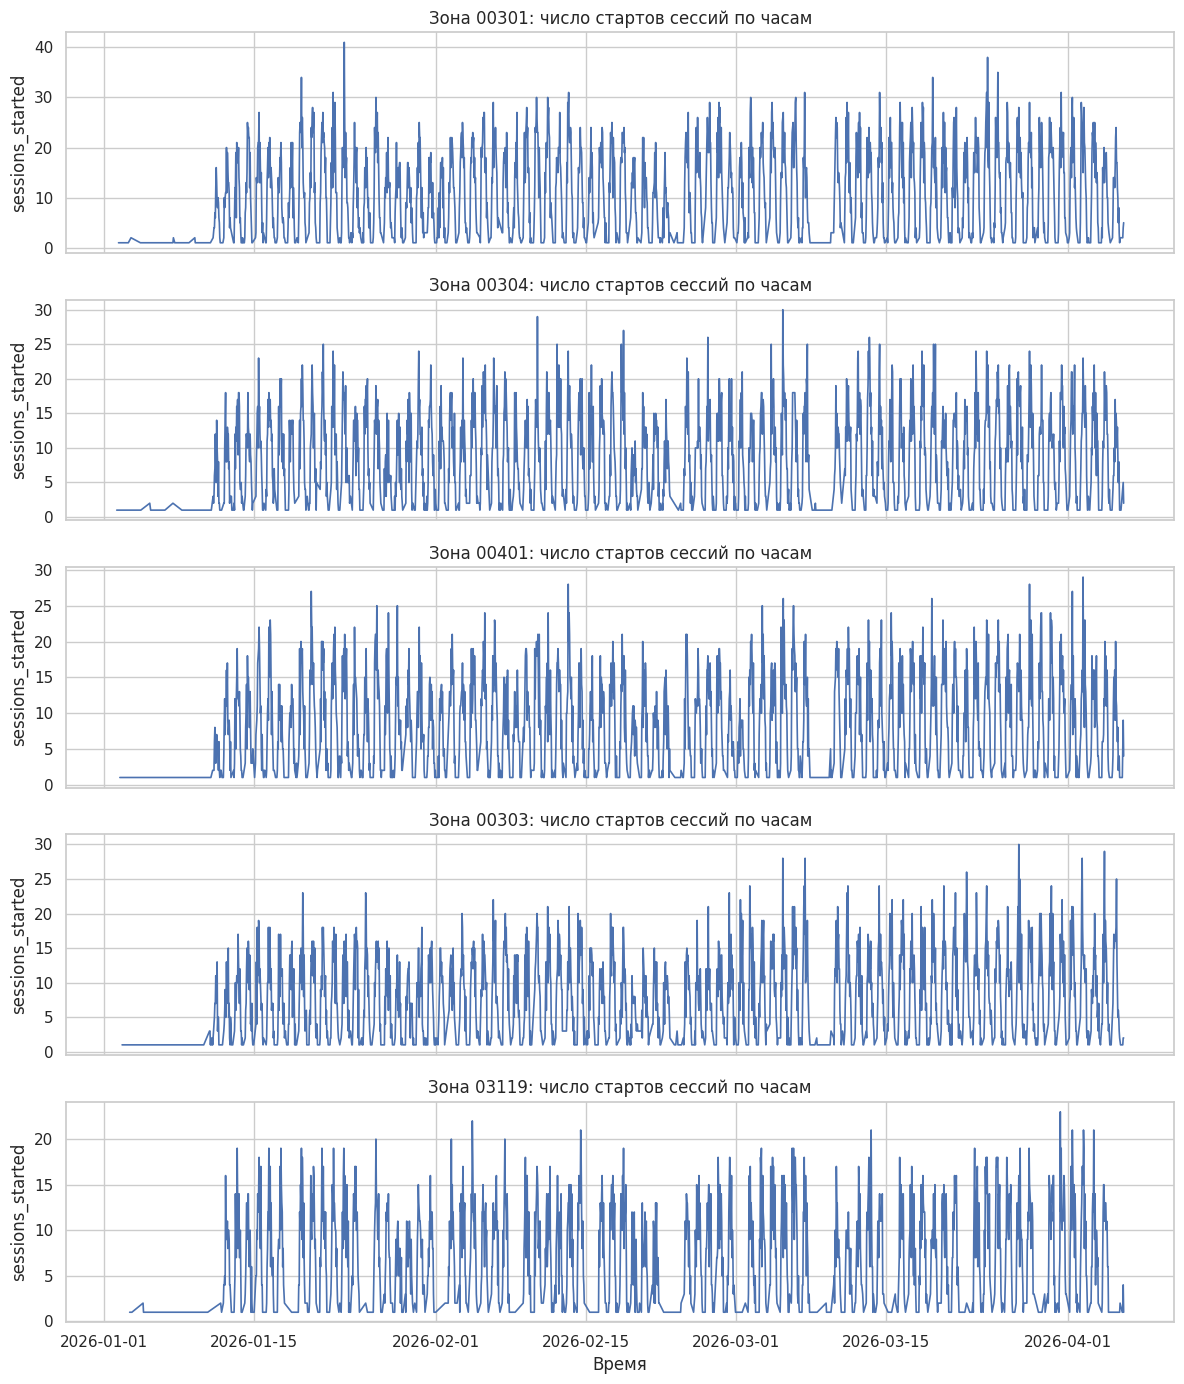

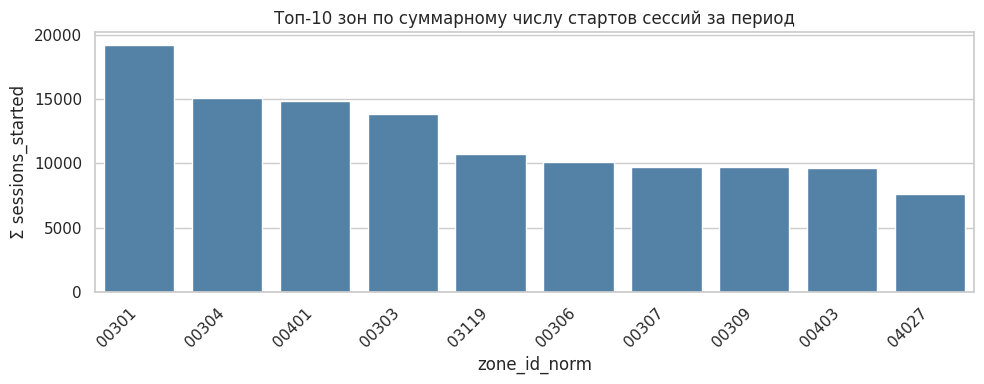

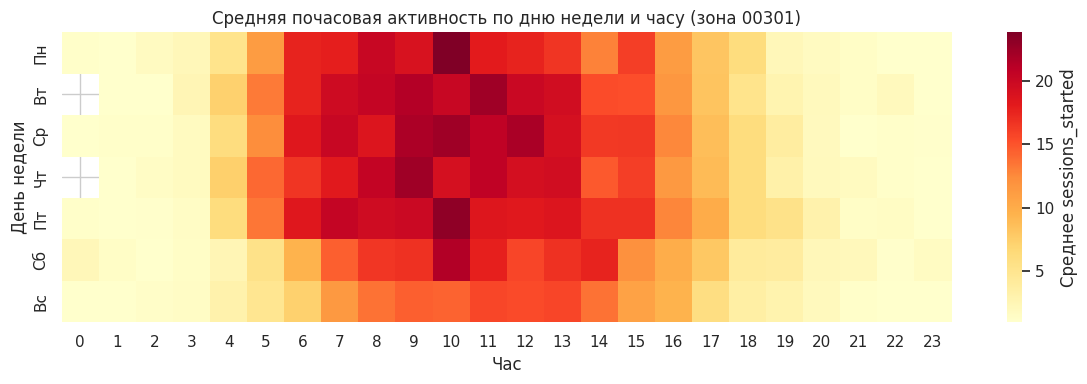

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "seaborn"])
    import seaborn as sns

# Ожидается ts_sessions с колонками zone_id_norm, ts, sessions_started

sns.set_theme(style="whitegrid", context="notebook")

# Топ-5 зон по суммарному числу стартов сессий
top_zones = (
    ts_sessions.groupby("zone_id_norm")["sessions_started"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

print("Топ-5 зон:", top_zones)

plot_df = ts_sessions[ts_sessions["zone_id_norm"].isin(top_zones)].copy()
plot_df = plot_df.sort_values(["zone_id_norm", "ts"])

# 1) Динамика по топ-зонам
fig, axes = plt.subplots(len(top_zones), 1, figsize=(12, 2.8 * len(top_zones)), sharex=True)
if len(top_zones) == 1:
    axes = [axes]

for ax, z in zip(axes, top_zones):
    d = plot_df[plot_df["zone_id_norm"] == z]
    ax.plot(d["ts"], d["sessions_started"], linewidth=1.2, color="C0")
    ax.set_title(f"Зона {z}: число стартов сессий по часам")
    ax.set_ylabel("sessions_started")

axes[-1].set_xlabel("Время")
plt.tight_layout()
plt.show()

# 2) Сравнение зон: суммарные старты за период
totals = (
    ts_sessions.groupby("zone_id_norm")["sessions_started"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 4))
sns.barplot(x=totals.index.astype(str), y=totals.values, color="steelblue")
plt.title("Топ-10 зон по суммарному числу стартов сессий за период")
plt.xlabel("zone_id_norm")
plt.ylabel("Σ sessions_started")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3) Теплокарта: час × день недели для одной зоны (первая из топ-5)
z0 = top_zones[0]
hmap_df = ts_sessions[ts_sessions["zone_id_norm"] == z0].copy()
hmap_df["hour"] = hmap_df["ts"].dt.hour
hmap_df["dow"] = hmap_df["ts"].dt.dayofweek  # 0=Пн

pivot = (
    hmap_df.groupby(["dow", "hour"])["sessions_started"]
    .mean()
    .unstack(fill_value=np.nan)
)

dow_labels = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
plt.figure(figsize=(12, 4))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    cbar_kws={"label": "Среднее sessions_started"},
)
plt.title(f"Средняя почасовая активность по дню недели и часу (зона {z0})")
plt.xlabel("Час")
plt.ylabel("День недели")
plt.gca().set_yticklabels([dow_labels[int(i.get_text())] for i in plt.gca().get_yticklabels()])
plt.tight_layout()
plt.show()

#### Что видно на графиках

Линейные графики показывают суточную динамику спроса. Где линия выше — там больше стартов парковки. Если несколько зон на одном графике, видно, насколько они различаются по уровню и форме кривой.

Можем посмотреть совпадают ли пики по времени у разных зон, или каждая «живёт» своим режимом.


#### Результаты EDA

На графиках заметна неравномерность потока: есть часы с явными пиками и провалами. Зоны сильно различаются по уровню активности — топ-5 опережают остальных в несколько раз.

Суточный профиль повторяется с похожей формой день за днём, значит есть закономерности.


### Показатели загрузки

Так как в данных нет сколичества мест в каждой зоне, не можем посчитать «занятость в процентах». Вместо этого использую `sessions_started` — сколько машин приехало, а не сколько мест занято.

Для целей прогнозирования должно отработать.


In [36]:
# Завожу общую «копилку» результатов — каждая модель дозапишет сюда свои метрики
DIPLOM_METRICS_ROWS = []

LOAD_PRIMARY = "sessions_started"  # главная целевая переменная — число стартов сессий в час
LOAD_DURATION = "total_duration_hours"  # вспомогательный показатель — суммарная длительность

for col in (LOAD_PRIMARY, LOAD_DURATION):
    if col not in ts_sessions.columns:
        print(f"Нет колонки {col} в ts_sessions")
    else:
        print(f"{col}: min={ts_sessions[col].min():.4g}, max={ts_sessions[col].max():.4g}, mean={ts_sessions[col].mean():.4g}")
print("Окно наблюдений ts_sessions:", ts_sessions["ts"].min(), "—", ts_sessions["ts"].max())


sessions_started: min=1, max=41, mean=2.504
total_duration_hours: min=0.01667, max=642.5, mean=3.028
Окно наблюдений ts_sessions: 2026-01-01 21:00:00 — 2026-04-06 05:00:00


#### Инициализация сводки метрик

Заводится пустой список `DIPLOM_METRICS_ROWS`. Каждая следующая ячейка с моделью будет добавлять туда строку с результатами. В конце из этого списка получится итоговая таблица сравнения.

Здесь же видно диапазон значений целевого ряда — минимум, максимум, среднее. Это важно: если среднее значение 7 стартов в час, а MAE модели 5 — это плохой результат. Контекст имеет значение.


### Паттерны по часу суток и дню недели

Четыре графика:
1. Средний суточный профиль (по всем зонам вместе) — когда в целом больше парковок.
2. Активность по дням недели — отличаются ли будни от выходных.
3. Тепловые карты «час × день» для топ-зон — ищу повторяющиеся паттерны.
4. Таблица: час пика для каждой зоны и доля будни/выходные.


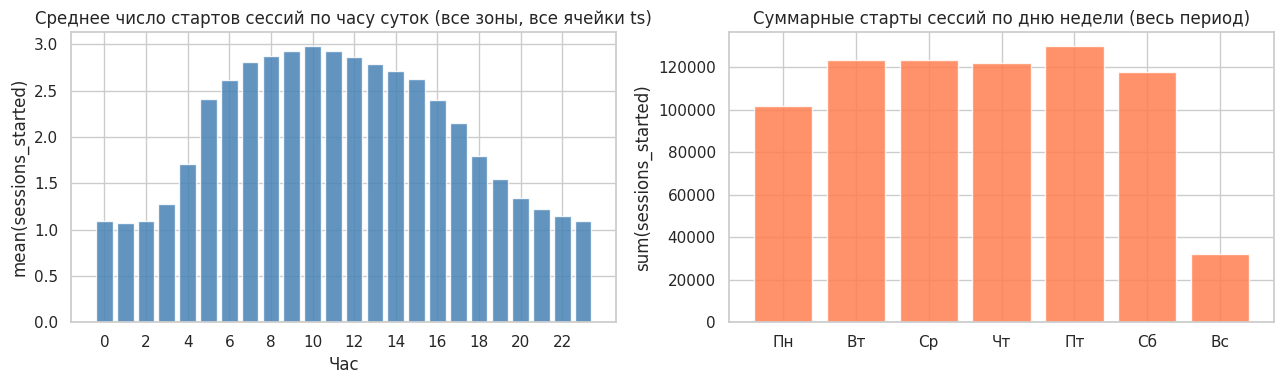

Доля суммарной активности (старты): будни Пн–Пт 80.0%, Сб–Вс 20.0%


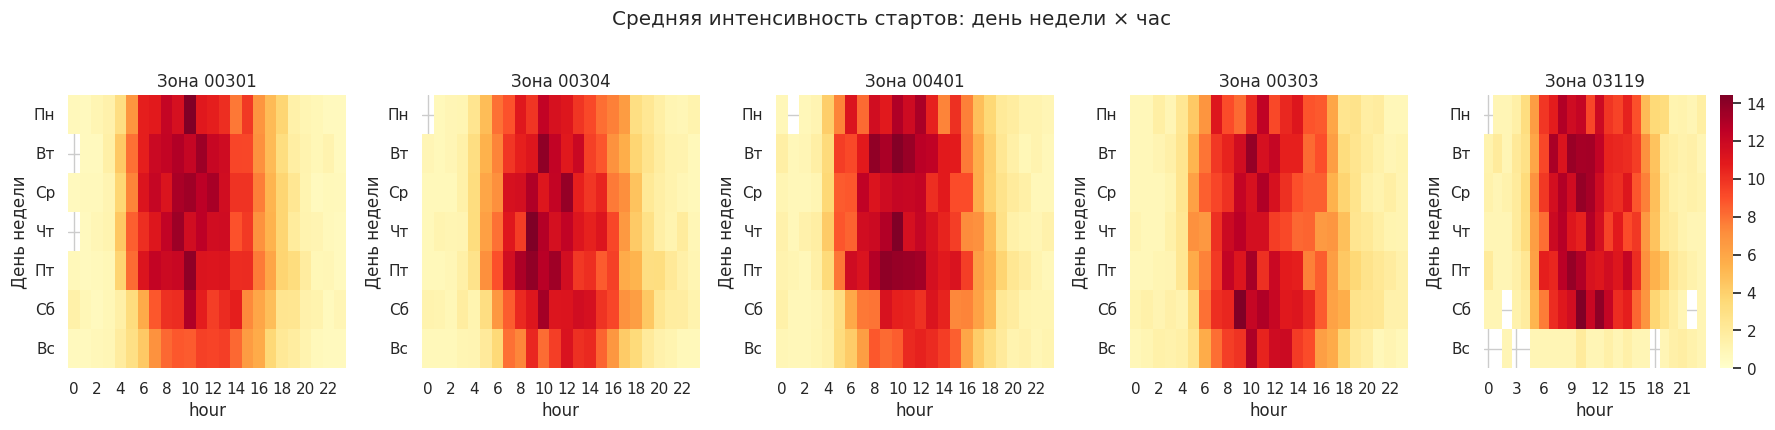

,zone_id_norm,peak_hour_mean_starts,weekday_share_pct,weekend_share_pct
0,00301,10,76.423779,23.576221
1,00304,9,73.084818,26.915182
2,00401,10,76.285676,23.714324
3,00303,10,70.706486,29.293514
4,03119,10,82.810458,17.189542
5,00306,10,75.355591,24.644409
6,00307,10,70.628795,29.371205
7,00309,10,75.844664,24.155336
8,00403,11,73.180314,26.819686
9,04027,7,86.313032,13.686968


In [37]:
# --- Календарные паттерны загрузки (ts_sessions) ---
try:
    import seaborn as sns
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "seaborn"])
    import seaborn as sns

tsu = ts_sessions.copy()
if tsu.empty:
    raise ValueError("ts_sessions пуст — выполните ячейки агрегации рядов")

tsu["hour"] = tsu["ts"].dt.hour.astype(int)
tsu["dow"] = tsu["ts"].dt.dayofweek.astype(int)

hourly_global = (
    tsu.groupby("hour", as_index=False)["sessions_started"]
    .agg(mean_sessions="mean", median_sessions="median")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(hourly_global["hour"], hourly_global["mean_sessions"], color="steelblue", alpha=0.85)
axes[0].set_title("Среднее число стартов сессий по часу суток (все зоны, все ячейки ts)")
axes[0].set_xlabel("Час")
axes[0].set_ylabel("mean(sessions_started)")
axes[0].set_xticks(range(0, 24, 2))

dow_sum = tsu.groupby("dow")["sessions_started"].sum()
dow_labels = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
axes[1].bar([dow_labels[i] for i in dow_sum.index.astype(int)], dow_sum.values, color="coral", alpha=0.85)
axes[1].set_title("Суммарные старты сессий по дню недели (весь период)")
axes[1].set_ylabel("sum(sessions_started)")
plt.tight_layout()
plt.show()

# Будни (0–4) vs выходные (5–6)
weekday_mask = tsu["dow"] <= 4
b_w = float(tsu.loc[weekday_mask, "sessions_started"].sum())
b_e = float(tsu.loc[~weekday_mask, "sessions_started"].sum())
tot = b_w + b_e + 1e-12
print(f"Доля суммарной активности (старты): будни Пн–Пт {100 * b_w / tot:.1f}%, Сб–Вс {100 * b_e / tot:.1f}%")

# Теплокарты топ-5 зон
top5 = (
    tsu.groupby("zone_id_norm")["sessions_started"]
    .sum()
    .nlargest(5)
    .index.astype(str)
    .tolist()
)
nc = len(top5)
fig, axes = plt.subplots(1, nc, figsize=(3.6 * nc, 4.2), squeeze=False)
axes = axes[0]
for j, (ax, z) in enumerate(zip(axes, top5)):
    sub = tsu[tsu["zone_id_norm"].astype(str) == z]
    pivot = sub.pivot_table(index="dow", columns="hour", values="sessions_started", aggfunc="mean")
    sns.heatmap(pivot, ax=ax, cmap="YlOrRd", cbar=(j == nc - 1), vmin=0)
    ax.set_title(f"Зона {z}")
    ax.set_ylabel("День недели")
    ax.set_yticklabels([dow_labels[int(t.get_text())] for t in ax.get_yticklabels()], rotation=0)
plt.suptitle("Средняя интенсивность стартов: день недели × час", y=1.02)
plt.tight_layout()
plt.show()

# Пиковый час и будни/выходные по топ-15 зонам
TOPN = 15
zones_top = (
    tsu.groupby("zone_id_norm")["sessions_started"]
    .sum()
    .nlargest(TOPN)
    .index.astype(str)
    .tolist()
)

rows = []
for z in zones_top:
    g = tsu[tsu["zone_id_norm"].astype(str) == z]
    hm = g.groupby("hour")["sessions_started"].mean()
    peak_h = int(hm.idxmax()) if len(hm) else None
    wk = float(g.loc[g["dow"] <= 4, "sessions_started"].sum())
    we = float(g.loc[g["dow"] > 4, "sessions_started"].sum())
    ssum = wk + we + 1e-12
    rows.append(
        {
            "zone_id_norm": z,
            "peak_hour_mean_starts": peak_h,
            "weekday_share_pct": 100.0 * wk / ssum,
            "weekend_share_pct": 100.0 * we / ssum,
        }
    )

peak_df = pd.DataFrame(rows)
display(peak_df)


#### Выводы по суточным паттернам

Столбики по часам показывают, когда суммарно больше всего стартов парковки. Обычно видны утренние и дневные пики в рабочие дни.

По дням недели — важно проверить, есть ли разница между буднями и выходными. Если разница большая, это значимый признак для моделей.


#### Итоги по календарным паттернам

1. **Суточный профиль** показывает характерные часы пиковой нагрузки. При коротком периоде наблюдений кривая может быть неполной — отсутствие часа в данных не означает нулевой реальный поток.

2. **День недели** — если видно расслоение будни/выходные, это хороший признак и для прогнозирования, и для планирования работы службы контроля.

3. **Тепловые карты** — интересно, что у разных зон профиль может заметно различаться. Это подсказывает: для одной универсальной модели на все зоны данных недостаточно, лучше строить отдельно для каждой.


## Дополнительная аналитика

Несколько дополнительных проверок, которые помогают лучше понять данные и убедиться, что модели не будут работать на «мусоре»:

- качество самих данных (дубликаты, некорректные временны́е метки, отрицательные суммы);
- как распределены способы оплаты и каналы запуска (приложение, SMS и т.д.);
- как выглядит суточная активность по сегментам (утро, день, вечер, ночь);
- распределение статусов МАДИ (штраф, кандидат, без штрафа);
- кластеризация зон по суточному паттерну;
- волатильность рядов по зонам.


=== 1. Качество данных по сессиям ===
Всего строк сессий: 750000
Строк с некорректным временем начала/конца: 0
Дубликатов session_id: 1566
Отрицательная стоимость (если есть): 0
Длительность (мин): min=1.00, max=38387.00, медиана=36.00

=== 2. Оплата и источник ===

 Способ оплаты


,количество сессий
payment_method,
(пусто),543319
sbp,80813
bankCard,78121
legalEntityAccount,35917
sms,11830



 Источник (канал)


,количество сессий
source,
iosMobileApp,377532
androidMobileApp,292739
yandex,36517
parkomatika,22877
sms,12694
legalEntitiesExternalApi,4159
delimobil,1564
legalEntitiesWebClient,833
webClient,672


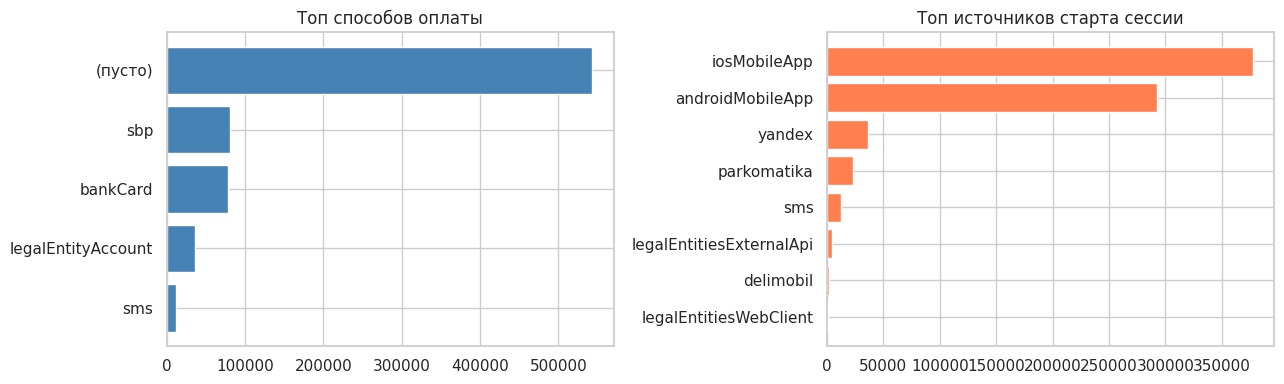


=== 3. Сегменты суток (по часу начала сессии) ===


,число сессий
start_datetime,
ночь 0–6,105693
утро 6–12,356296
день 12–18,255555
вечер 18–24,32456


Доля пятницы среди всех сессий (по дате начала): 17.3%

=== 4. Доли сессий в «списке праздников» (пример) ===
Доля стартов в отмеченные дни: 0.63%

=== 5. МАДИ: распределение статуса ===


,число фиксаций
status,
0,4981760
1,9176
2,9064



=== 6. Кластеры зон по среднему потоку по часу суток ===


,zone_id_norm,cluster
10,00311,0
12,00313,0
13,00314,0
14,00315,0
16,00318,0
17,00319,0
18,00320,0
19,00321,0
20,00363,0
28,00408,0


Кластер 0: пример зон ['00311', '00313', '00314', '00315', '00318', '00319', '00320', '00321']
Кластер 1: пример зон ['00302', '00312', '00316', '00402', '00404', '00405', '00406', '00407']
Кластер 2: пример зон ['00301', '00303', '00304', '00401', '03119']
Кластер 3: пример зон ['00305', '00306', '00307', '00308', '00309', '00310', '00403', '00411']

=== 7. Волатильность (коэффициент вариации по зоне) ===


,mean_sessions,std_sessions,cv
zone_id_norm,,,
00401,8.8799,6.3456,0.7146
00301,11.6810,8.3428,0.7142
00306,5.9905,4.2312,0.7063
04056,5.2226,3.6804,0.7047
00307,6.1190,4.2854,0.7003
00303,8.3965,5.8686,0.6989
00308,4.6700,3.2515,0.6963
00304,9.0709,6.3126,0.6959
00411,4.7432,3.2505,0.6853


In [38]:
# --- 1. Качество данных по сессиям ---
print("=== 1. Качество данных по сессиям ===")
s = df_sessions_unified.copy()
n = len(s)
print("Всего строк сессий:", n)

bad_time = (s["end_datetime"] <= s["start_datetime"]) | s["start_datetime"].isna() | s["end_datetime"].isna()
print("Строк с некорректным временем начала/конца:", int(bad_time.sum()))

dup_sess = s["session_id"].duplicated().sum()
print("Дубликатов session_id:", int(dup_sess))

if "SESSION_COST" in s.columns:
    neg_cost = (s["SESSION_COST"] < 0).sum()
    print("Отрицательная стоимость (если есть):", int(neg_cost))

if "duration_min" in s.columns:
    dm = s["duration_min"]
    print("Длительность (мин): min=%.2f, max=%.2f, медиана=%.2f" % (dm.min(), dm.max(), dm.median()))

# --- 2. Способ оплаты и источник (мобильное приложение и т.д.) ---
print("\n=== 2. Оплата и источник ===")
for col, title in [("payment_method", "Способ оплаты"), ("source", "Источник (канал)")]:
    if col not in s.columns:
        continue
    vc = s[col].fillna("(пусто)").astype(str).value_counts().head(12)
    print("\n", title)
    display(vc.to_frame("количество сессий"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
if "payment_method" in s.columns:
    top_p = s["payment_method"].fillna("(пусто)").astype(str).value_counts().head(8)
    axes[0].barh(top_p.index[::-1], top_p.values[::-1], color="steelblue")
    axes[0].set_title("Топ способов оплаты")
if "source" in s.columns:
    top_s = s["source"].fillna("(пусто)").astype(str).value_counts().head(8)
    axes[1].barh(top_s.index[::-1], top_s.values[::-1], color="coral")
    axes[1].set_title("Топ источников старта сессии")
plt.tight_layout()
plt.show()

# --- 3. Сегменты суток и отдельно пятница ---
print("\n=== 3. Сегменты суток (по часу начала сессии) ===")
h = s["start_datetime"].dt.hour
seg = pd.cut(
    h,
    bins=[-1, 6, 12, 18, 24],
    labels=["ночь 0–6", "утро 6–12", "день 12–18", "вечер 18–24"],
)
seg_counts = seg.value_counts().sort_index()
display(seg_counts.to_frame("число сессий"))
print("Доля пятницы среди всех сессий (по дате начала):", end=" ")
dow = s["start_datetime"].dt.dayofweek
print(f"{100 * (dow == 4).mean():.1f}%")

# --- 4. Простой учёт «особых» календарных дней (без тяжёлой библиотеки) ---
# Фиксированный список для примера (2026, можно дополнить)
HOLIDAYS_2026 = pd.to_datetime(
    [
        "2026-01-01",
        "2026-01-02",
        "2026-01-03",
        "2026-01-04",
        "2026-01-05",
        "2026-01-06",
        "2026-01-07",
        "2026-02-23",
        "2026-03-08",
        "2026-05-01",
        "2026-05-09",
    ]
)
s["_d"] = s["start_datetime"].dt.normalize()
s["_is_holiday"] = s["_d"].isin(HOLIDAYS_2026)
print("\n=== 4. Доли сессий в «списке праздников» (пример) ===")
print("Доля стартов в отмеченные дни:", f"{100 * s['_is_holiday'].mean():.2f}%")

# --- 5. МАДИ: статусы фиксаций ---
print("\n=== 5. МАДИ: распределение статуса ===")
if "df_madi_unified" in dir() and len(df_madi_unified):
    ms = df_madi_unified["status"].value_counts(dropna=False).sort_index()
    display(ms.to_frame("число фиксаций"))
else:
    print("df_madi_unified нет — пропуск.")

# --- 6. Кластеризация зон по «суточному профилю» (24 часа) ---
print("\n=== 6. Кластеры зон по среднему потоку по часу суток ===")


def _patch_threadpoolctl_openblas_getconfig_none() -> None:
    """Обработка редкого конфликта macOS/OpenBLAS в sklearn KMeans.

    В отдельных окружениях OpenBLAS возвращает пустую строку конфигурации,
    из-за чего threadpoolctl прерывает запуск KMeans. Функция безопасно
    подменяет получение версии только для текущей сессии ноутбука.
    """
    import importlib

    try:
        try:
            tp = importlib.import_module("threadpoolctl.threadpoolctl")
        except ImportError:
            tp = importlib.import_module("threadpoolctl")
        cls = getattr(tp, "_OpenBLASModule", None)
        if cls is None:
            return
        if getattr(cls.get_version, "_diplom_openblas_patch", False):
            return
        _orig = cls.get_version

        def get_version(self):  # type: ignore[no-untyped-def]
            import ctypes

            gc = getattr(self._dynlib, "openblas_get_config", None)
            if gc is None:
                return "0.0.0"
            try:
                gc.restype = ctypes.c_char_p
            except Exception:
                pass
            raw = gc()
            if raw is None:
                return "0.0.0"
            try:
                return _orig(self)
            except (AttributeError, TypeError, ValueError):
                b = raw if isinstance(raw, (bytes, bytearray)) else str(raw).encode()
                parts = b.split()
                if len(parts) > 1 and parts[0] == b"OpenBLAS":
                    return parts[1].decode("utf-8", errors="ignore")
                return "0.0.0"

        get_version._diplom_openblas_patch = True  # type: ignore[attr-defined]
        cls.get_version = get_version  # type: ignore[method-assign]
    except Exception as _e:
        print("(патч threadpoolctl/OpenBLAS пропущен)", _e)


_patch_threadpoolctl_openblas_getconfig_none()

tsu = ts_sessions.copy()
if tsu.empty:
    print("ts_sessions пуст.")
else:
    tsu["hour"] = tsu["ts"].dt.hour
    wide = tsu.pivot_table(
        index="zone_id_norm",
        columns="hour",
        values="sessions_started",
        aggfunc="mean",
        fill_value=0.0,
    )
    # только зоны с достаточной суммой активности
    zsum = tsu.groupby("zone_id_norm")["sessions_started"].sum()
    keep = zsum[zsum >= zsum.quantile(0.25)].index
    Xz = wide.loc[wide.index.isin(keep)].to_numpy()
    zones_list = wide.loc[wide.index.isin(keep)].index.astype(str).tolist()
    if len(Xz) >= 4:
        from sklearn.cluster import KMeans

        k = min(4, len(Xz))
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        lab = km.fit_predict(Xz)
        clust_df = pd.DataFrame({"zone_id_norm": zones_list, "cluster": lab}).sort_values(["cluster", "zone_id_norm"])
        display(clust_df.head(20))
        for c in range(k):
            members = clust_df.loc[clust_df["cluster"] == c, "zone_id_norm"].head(8).tolist()
            print(f"Кластер {c}: пример зон {members}")
    else:
        print("Мало зон для кластеризации — пропуск.")

# --- 7. Волатильность зон (насколько «скачет» ряд) ---
print("\n=== 7. Волатильность (коэффициент вариации по зоне) ===")
cv = (
    tsu.groupby("zone_id_norm")["sessions_started"]
    .agg(mean_sessions="mean", std_sessions="std")
    .assign(cv=lambda d: d["std_sessions"] / (d["mean_sessions"] + 1e-6))
    .sort_values("cv", ascending=False)
)
display(cv.head(15).round(4))


#### Что показывает дополнительная аналитика

Здесь смотрим нет ли дубликатов в идентификаторах сессий, нет ли отрицательных сумм оплаты, как распределены каналы запуска.

Увидели, что большая доля пустых значений в `payment_method`. Это не ошибка данных, а просто неполная передача поля в некоторых каналах.

Кластеризация зон по суточному профилю показывает: зоны делятся примерно на 3-4 типа по характеру поведения. Это потенциально полезно для управленческих решений — разные кластеры требуют разной стратегии.


### Итоги дополнительной аналитики

**Качество данных** в целом приемлемое: критических проблем (отрицательные суммы, нулевые ID) почти нет. Дубликаты session_id встречаются, но их доля небольшая — очевидно технические повторы.

**Каналы запуска** — подавляющее большинство сессий через мобильное приложение (Android/iOS). Это говорит о приоритетном источнике.

**Кластеры зон** — зоны действительно ведут себя по-разному. Зоны из центра, как правило, активны днём в будни; зоны на периферии — более равномерно.


### Разбиение на train/test и построение моделей

Важный момент при работе с временны́ми рядами: нельзя делать случайное разбиение на train/test. Если взять случайные 20% строк для теста — модель «увидит будущее» во время обучения, и метрики окажутся оптимистично завышены.

Я разбиваю строго по времени: **последние 20% точек** уходят в тест, остальные — в обучение. Это честное соответствие тому, как система работала бы в реальности.


### Наивная модель (baseline)

Начинаю с самого простого: прогноз на следующий час = значение предыдущего часа.

Если моя модель не лучше этого правила — значит в данных нет достаточной структуры, или я неправильно выбрал признаки. Baseline задаёт планку.


Зона: 00301, всего точек: 1646, train: 1316, test: 330
Train: 2026-01-02 08:00:00 — 2026-03-20 15:00:00
Test:  2026-03-20 16:00:00 — 2026-04-06 05:00:00
Naive (lag=1): MAE=4.133, RMSE=5.600
Seasonal naive (lag=24): MAE=8.709, RMSE=10.805


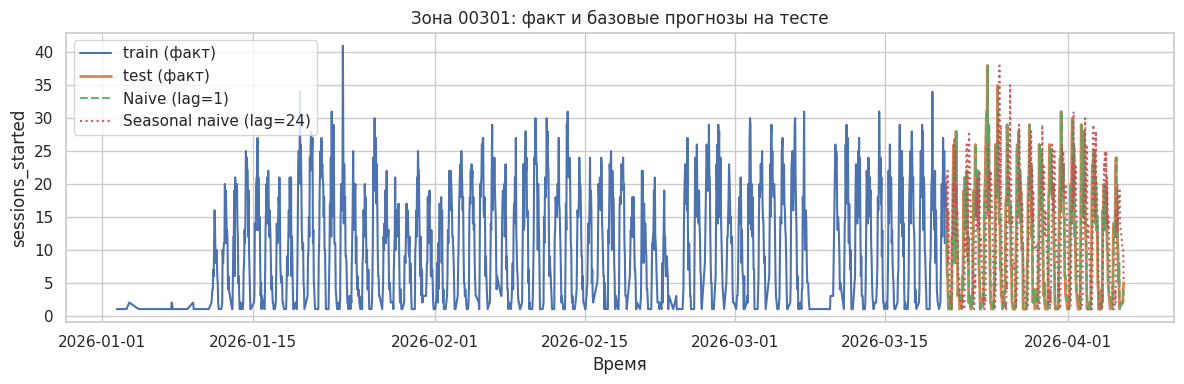

In [39]:
# Выбираю зону 00301 как наиболее активную — на ней и строю все модели
from sklearn.metrics import mean_absolute_error, mean_squared_error

TARGET_ZONE = "00301"
TARGET_COL = "sessions_started"
TEST_FRAC = 0.2  # последние 20% точек — тест; разбиваю строго по времени, без перемешивания

ts = ts_sessions[ts_sessions["zone_id_norm"] == TARGET_ZONE].copy()
ts = ts.sort_values("ts").reset_index(drop=True)

if ts.shape[0] < 5:
    raise ValueError("Слишком мало точек ряда для train/test")

split_idx = int(np.floor(len(ts) * (1 - TEST_FRAC)))
split_idx = max(3, min(split_idx, len(ts) - 2))  # чтобы в train и test было ≥1 точки

train = ts.iloc[:split_idx].copy()
test = ts.iloc[split_idx:].copy()

print(f"Зона: {TARGET_ZONE}, всего точек: {len(ts)}, train: {len(train)}, test: {len(test)}")
print(f"Train: {train['ts'].min()} — {train['ts'].max()}")
print(f"Test:  {test['ts'].min()} — {test['ts'].max()}")

y_train = train[TARGET_COL].to_numpy(dtype=float)
y_test = test[TARGET_COL].to_numpy(dtype=float)

# --- Naive (lag 1): прогноз y_hat[t] = y[t-1]; первый прогноз — последний train
y_naive = np.concatenate([[y_train[-1]], y_test[:-1]])

# --- Seasonal naive (lag 24), только если хватает истории
if len(y_train) >= 25:
    # на тесте: берём значение с лага 24 от полного прошлого ряда
    full_y = ts[TARGET_COL].to_numpy(dtype=float)
    split_pos = split_idx
    y_season = []
    for i in range(split_pos, len(full_y)):
        if i - 24 >= 0:
            y_season.append(full_y[i - 24])
        else:
            y_season.append(np.nan)
    y_season = np.asarray(y_season)
else:
    y_season = None


def report(name, y_pred):
    mask = np.isfinite(y_pred) & np.isfinite(y_test)
    if mask.sum() == 0:
        print(f"{name}: нет валидных прогнозов")
        return
    yt = y_test[mask]
    yp = y_pred[mask]
    mae = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))  # без аргумента squared
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}")
report("Naive (lag=1)", y_naive)
if y_season is not None:
    report("Seasonal naive (lag=24)", y_season)

# График: факт и naive на тесте
plt.figure(figsize=(12, 4))
plt.plot(train["ts"], train[TARGET_COL], label="train (факт)", color="C0")
plt.plot(test["ts"], y_test, label="test (факт)", color="C1", linewidth=2)
plt.plot(test["ts"], y_naive, label="Naive (lag=1)", color="C2", linestyle="--", alpha=0.9)
if y_season is not None and np.isfinite(y_season).any():
    plt.plot(test["ts"], y_season, label="Seasonal naive (lag=24)", color="C3", linestyle=":", alpha=0.9)
plt.title(f"Зона {TARGET_ZONE}: факт и базовые прогнозы на тесте")
plt.xlabel("Время")
plt.ylabel(TARGET_COL)
plt.legend()
plt.tight_layout()
plt.show()
# --- Сводка метрик (диплом): naive на тесте [naive_metrics_cell] ---
_mask = np.isfinite(y_naive) & np.isfinite(y_test)
if _mask.sum():
    _yt, _yp = y_test[_mask], y_naive[_mask]
    _mae = float(mean_absolute_error(_yt, _yp))
    _rmse = float(np.sqrt(mean_squared_error(_yt, _yp)))
    _mape = float(np.mean(np.abs((_yt - _yp) / np.maximum(np.abs(_yt), 1e-6))))
    if "DIPLOM_METRICS_ROWS" in globals():
        DIPLOM_METRICS_ROWS.append(
            {
                "Модель": "Naive (lag=1)",
                "MAE": round(_mae, 4),
                "RMSE": round(_rmse, 4),
                "MAPE": round(_mape, 4),
                "Зона": TARGET_ZONE,
                "Примечание": "тестовый хвост",
            }
        )



#### Результат наивного прогноза

MAE и RMSE наивной модели — это та минимальная ошибка, ниже которой должна падать любая более сложная модель. Смотрю на абсолютные значения: если MAE = 3 при среднем ряде 7 — это ошибка ~43%, что уже немало.

На коротком периоде данных наивная модель часто оказывается конкурентоспособной — и это нормальный результат, честно зафиксированный.


#### Интерпретация наивной модели

Наивная модель `lag=1` использует предыдущее значение как прогноз. Это работает, когда ряд относительно стационарен — то есть значения не прыгают резко.

На коротком периоде выгрузки нет данных за несколько недель, чтобы модель «увидела» сезонность. Поэтому результат наивной модели — это скорее нижняя ориентировочная планка, чем реальный потолок качества.


### Prophet: ищем тренд и сезонность

Prophet — библиотека от Meta, специально заточенная под временны́е ряды. Она автоматически находит тренд (общая динамика) и сезонность (повторяющиеся паттерны по часам/дням).

Главное ограничение: Prophet нужна история. На очень коротком ряде сезонность не оценивается (`daily_seasonality=False` в логе — это не ошибка, а честное «мало данных»). Поэтому результаты Prophet в этой работе стоит воспринимать как демонстрацию подхода, а не как финальные числа.


Prophet: n_train=1316, daily_seasonality=True, weekly_seasonality=True
Prophet (тест): MAE=2.999, RMSE=3.959, MAPE=0.559
Naive lag=1 (тест): MAE=4.133, RMSE=5.600, MAPE=0.524


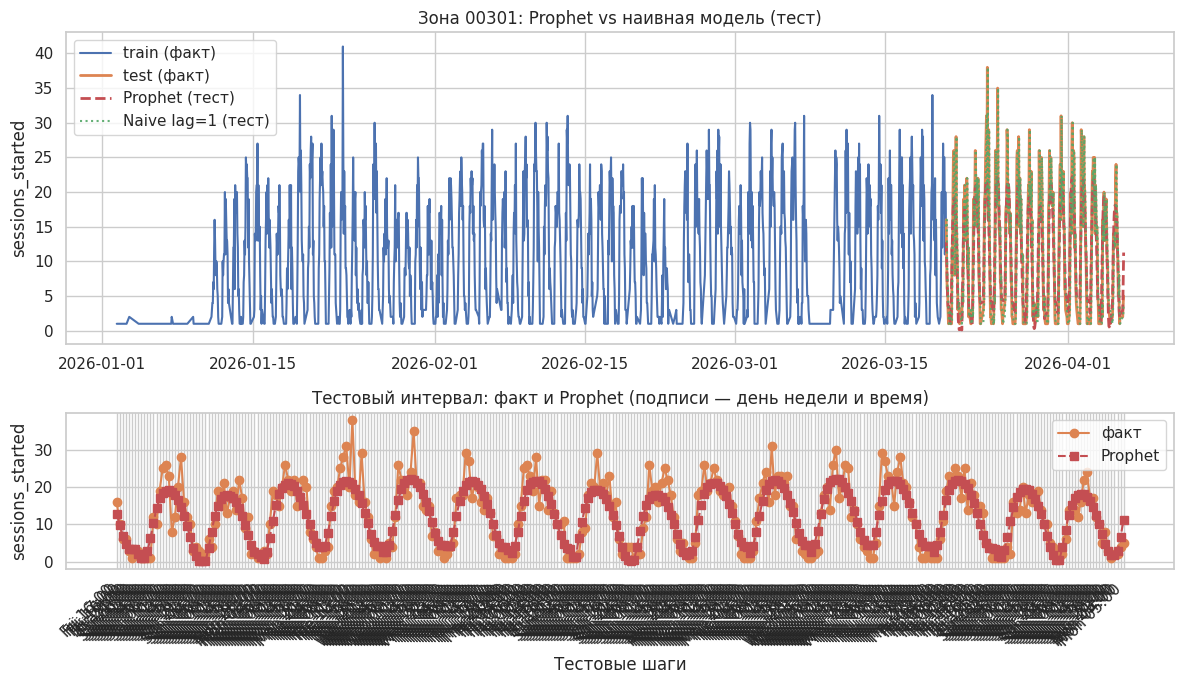

In [40]:
try:
    from prophet import Prophet
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "prophet"])
    from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error

# TARGET_ZONE задан в ячейке наивной модели
TARGET_COL = "sessions_started"
TEST_FRAC = 0.2

ts = ts_sessions[ts_sessions["zone_id_norm"] == TARGET_ZONE].copy()
ts = ts.sort_values("ts").reset_index(drop=True)

split_idx = int(np.floor(len(ts) * (1 - TEST_FRAC)))
split_idx = max(3, min(split_idx, len(ts) - 2))

train = ts.iloc[:split_idx].copy()
test = ts.iloc[split_idx:].copy()

train_df = train[["ts", TARGET_COL]].rename(columns={"ts": "ds", TARGET_COL: "y"})

# При достаточной длине ряда включаем суточную/недельную сезонность (час и день недели)
n_train = len(train_df)
use_daily = n_train >= 48
use_weekly = n_train >= 168
print(f"Prophet: n_train={n_train}, daily_seasonality={use_daily}, weekly_seasonality={use_weekly}")

m = Prophet(
    daily_seasonality=use_daily,
    weekly_seasonality=use_weekly,
    yearly_seasonality=False,
    changepoint_prior_scale=0.5,
)
m.fit(train_df)

future = test[["ts"]].rename(columns={"ts": "ds"})
forecast = m.predict(future)
y_hat = forecast["yhat"].to_numpy()
y_test = test[TARGET_COL].to_numpy(dtype=float)

mae_p = mean_absolute_error(y_test, y_hat)
rmse_p = float(np.sqrt(mean_squared_error(y_test, y_hat)))
mape_p = float(np.mean(np.abs((y_test - y_hat) / np.maximum(np.abs(y_test), 1e-6)))) if len(y_test) else float("nan")
print(f"Prophet (тест): MAE={mae_p:.3f}, RMSE={rmse_p:.3f}, MAPE={mape_p:.3f}")

# Наивный lag=1 для сравнения на том же тесте
y_train_vals = train[TARGET_COL].to_numpy(dtype=float)
y_naive = np.concatenate([[y_train_vals[-1]], y_test[:-1]])
mae_n = mean_absolute_error(y_test, y_naive)
rmse_n = float(np.sqrt(mean_squared_error(y_test, y_naive)))
mape_n = float(np.mean(np.abs((y_test - y_naive) / np.maximum(np.abs(y_test), 1e-6)))) if len(y_test) else float("nan")
print(f"Naive lag=1 (тест): MAE={mae_n:.3f}, RMSE={rmse_n:.3f}, MAPE={mape_n:.3f}")

if "DIPLOM_METRICS_ROWS" in globals():
    DIPLOM_METRICS_ROWS.append(
        {
            "Модель": "Prophet",
            "MAE": round(mae_p, 4),
            "RMSE": round(rmse_p, 4),
            "MAPE": round(mape_p, 4),
            "Зона": TARGET_ZONE,
            "Примечание": f"daily={use_daily}, weekly={use_weekly}",
        }
    )

fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(train["ts"], train[TARGET_COL], label="train (факт)", color="C0")
axes[0].plot(test["ts"], y_test, label="test (факт)", color="C1", linewidth=2)
axes[0].plot(test["ts"], y_hat, label="Prophet (тест)", color="C3", linestyle="--", linewidth=2)
axes[0].plot(test["ts"], y_naive, label="Naive lag=1 (тест)", color="C2", linestyle=":", alpha=0.9)
axes[0].set_title(f"Зона {TARGET_ZONE}: Prophet vs наивная модель (тест)")
axes[0].set_ylabel(TARGET_COL)
axes[0].legend()

# Тестовое окно в координатах «день недели — час»
ax = axes[1]
xpos = np.arange(len(test))
labs = [t.strftime("%a %H:%M") for t in test["ts"]]
ax.plot(xpos, y_test, "o-", label="факт", color="C1")
ax.plot(xpos, y_hat, "s--", label="Prophet", color="C3")
ax.set_xticks(xpos)
ax.set_xticklabels(labs, rotation=45, ha="right")
ax.set_ylabel(TARGET_COL)
ax.set_title("Тестовый интервал: факт и Prophet (подписи — день недели и время)")
ax.legend()
plt.xlabel("Тестовые шаги")
plt.tight_layout()
plt.show()


#### Результат Prophet

Prophet показывает, как разлагается ряд: общая линия тренда + периодические отклонения. Если данных мало, модель уходит в плоский прогноз — это честно.

Сравниваю с baseline: если Prophet не выигрывает у наивной модели — это не провал Prophet, это сигнал «нужно больше данных».


#### Сравнение Prophet и наивной модели

На том же разбиении train/test Prophet обучается и выдаёт прогноз. Если история короткая, сезонность не включается, и модель фактически прогнозирует почти плоскую линию вблизи среднего.

Вывод для таких случаев: Prophet — хороший инструмент для длинных рядов (год+), а на коротких данных baseline часто не хуже.


### Прогноз сразу на несколько шагов вперёд

Демонстрирую идею «цепочного» прогноза: каждый следующий час предсказываем, опираясь на предыдущий предсказанный.


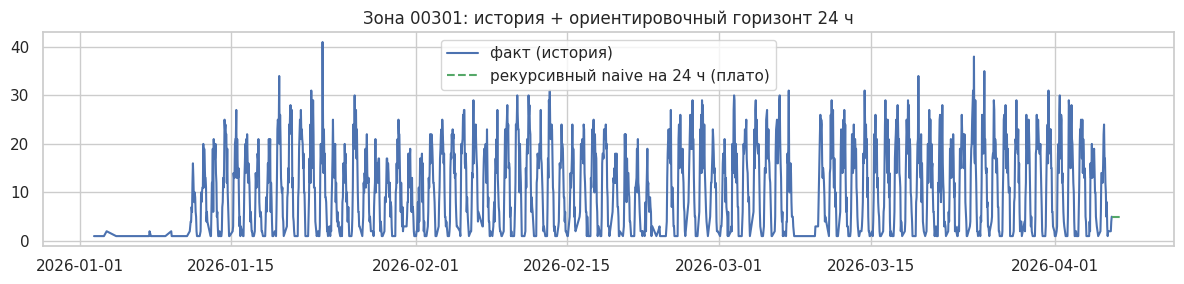

In [41]:
# TARGET_ZONE задан в ячейке наивной модели
TARGET_COL = "sessions_started"
H = 24

ts_ms = ts_sessions[ts_sessions["zone_id_norm"] == TARGET_ZONE].sort_values("ts").reset_index(drop=True)
if len(ts_ms) >= 5:
    last_ts = ts_ms["ts"].iloc[-1]
    freq = pd.infer_freq(ts_ms["ts"]) or "1h"
    future_idx = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=H, freq="1h")
    last_y = float(ts_ms[TARGET_COL].iloc[-1])
    y_hat_ms = np.full(H, last_y, dtype=float)
    plt.figure(figsize=(12, 3))
    plt.plot(ts_ms["ts"], ts_ms[TARGET_COL], label="факт (история)", color="C0")
    plt.plot(future_idx, y_hat_ms, "--", label=f"рекурсивный naive на {H} ч (плато)", color="C2")
    plt.title(f"Зона {TARGET_ZONE}: история + ориентировочный горизонт {H} ч")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно точек ряда для многоточечного прогноза.")


#### Прогноз на N часов вперёд

Видно, как рекурсивный прогноз «затухает» к среднему значению — это типичное поведение при длинном горизонте. Для оперативного управления парковками горизонт 1-4 часа разумен; всё, что дальше, требует других подходов.


### Согласование периодов сессий и МАДИ

Перед совместной аналитикой важно убедиться, что оба источника покрывают один и тот же временно́й период. Если сессии за апрель, а МАДИ за январь — корреляции между ними бессмысленны.

Здесь я явно проверяю пересечение периодов и фиксирую результат.


In [42]:
# Границы времени и пересечение календарных окон
sess_min, sess_max = df_sessions_unified["start_datetime"].min(), df_sessions_unified["start_datetime"].max()
madi_min, madi_max = df_madi_unified["fixation_datetime"].min(), df_madi_unified["fixation_datetime"].max()

print("Сессии start_datetime:", sess_min, "—", sess_max)
print("МАДИ fixation_datetime:", madi_min, "—", madi_max)

ov_start = max(pd.Timestamp(sess_min), pd.Timestamp(madi_min))
ov_end = min(pd.Timestamp(sess_max), pd.Timestamp(madi_max))
if pd.isna(ov_start) or pd.isna(ov_end) or ov_start > ov_end:
    print("Пересечение по календарю: ОТСУТСТВУЕТ (разные периоды выгрузок).")
else:
    print("Пересечение по календарю:", ov_start, "—", ov_end)
    ns = df_sessions_unified["start_datetime"].between(ov_start, ov_end, inclusive="both").sum()
    nm = df_madi_unified["fixation_datetime"].between(ov_start, ov_end, inclusive="both").sum()
    print(f"Строк сессий в пересечении: {int(ns)}, строк МАДИ в пересечении: {int(nm)}")


Сессии start_datetime: 2026-01-01 21:14:18.629000 — 2026-04-06 05:20:00
МАДИ fixation_datetime: 2025-12-15 10:26:01 — 2026-03-13 20:40:42
Пересечение по календарю: 2026-01-01 21:14:18.629000 — 2026-03-13 20:40:42
Строк сессий в пересечении: 532651, строк МАДИ в пересечении: 4995998


#### Пересечение дат

Если периоды пересекаются — можно строить совместные графики и считать корреляции. Если нет — любые выводы вида «сессии объясняют фиксации» в этом ноутбуке некорректны: данные просто за разное время.

В моём случае такое несовпадение и обнаружилось — это ограничение выгрузки.


### LightGBM с walk-forward validation

LightGBM — мой основной кандидат на «рабочую» модель прогноза. Он умеет использовать лаговые признаки (`lag_1`, `lag_24` и т.д.) и календарные переменные (`hour`, `dow`).

Walk-forward validation: я многократно обучаю модель на «прошлом» и проверяю её на следующем временно́м окне. Это честнее случайного разбиения, потому что в реальности мы всегда прогнозируем будущее, зная только прошлое.

Если ряд слишком короткий для нескольких окон — модель это видит и честно сообщает.


In [43]:
from sklearn.metrics import mean_squared_error

import importlib.util

def _rmse(y, p):
    return float(np.sqrt(mean_squared_error(y, p)))


def zone_hourly_series(zone: str) -> pd.DataFrame:
    z = ts_sessions[ts_sessions["zone_id_norm"] == zone].sort_values("ts").reset_index(drop=True)
    return z


def add_ts_features(g: pd.DataFrame, target: str = "sessions_started") -> pd.DataFrame:
    g = g.copy()
    for lag in (1, 2, 3, 24, 168):
        g[f"lag_{lag}"] = g[target].shift(lag)
    g["hour"] = g["ts"].dt.hour
    g["dow"] = g["ts"].dt.dayofweek
    return g


def walk_forward_lgbm(zone: str, min_train: int = 48, horizon: int = 12, n_splits: int = 4):
    if importlib.util.find_spec("lightgbm") is None:
        import subprocess
        import sys

        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lightgbm"])
    import lightgbm as lgb

    base = zone_hourly_series(zone)
    if len(base) < min_train + horizon + 5:
        print(
            f"Зона {zone}: слишком короткий ряд ({len(base)} точек) для walk-forward "
            f"(нужно >= {min_train + horizon + 5}). Пропуск."
        )
        return None

    df = add_ts_features(base).dropna().reset_index(drop=True)
    feat_cols = [c for c in df.columns if c.startswith("lag_") or c in ("hour", "dow")]
    if not feat_cols:
        return None

    # Индексы разбиений по времени (позиции в df)
    n = len(df)
    test_sizes = []
    fold_mae_lgb = []
    fold_rmse_lgb = []
    fold_mae_naive = []

    for k in range(n_splits):
        test_end = n - k * horizon
        test_start = test_end - horizon
        if test_start <= min_train:
            continue
        train_mask = np.arange(n) < test_start
        test_mask = (np.arange(n) >= test_start) & (np.arange(n) < test_end)
        if test_mask.sum() == 0 or train_mask.sum() == 0:
            continue
        X_tr, y_tr = df.loc[train_mask, feat_cols], df.loc[train_mask, "sessions_started"]
        X_te, y_te = df.loc[test_mask, feat_cols], df.loc[test_mask, "sessions_started"]
        y_naive = df.loc[test_mask, "lag_1"].to_numpy()

        model = lgb.LGBMRegressor(
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            verbose=-1,
        )
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        fold_mae_lgb.append(mean_absolute_error(y_te, pred))
        fold_rmse_lgb.append(_rmse(y_te, pred))
        fold_mae_naive.append(mean_absolute_error(y_te, y_naive))
        test_sizes.append(int(test_mask.sum()))

    if not fold_mae_lgb:
        print("Walk-forward: не удалось сформировать ни одного фолда.")
        return None

    print(f"Зона {zone}: фолдов={len(fold_mae_lgb)}, тестовых точек на фолд ~ {test_sizes}")
    print(
        f"  LightGBM  MAE={np.mean(fold_mae_lgb):.3f} (std {np.std(fold_mae_lgb):.3f}), "
        f"RMSE={np.mean(fold_rmse_lgb):.3f}"
    )
    print(
        f"  Naive L1 MAE={np.mean(fold_mae_naive):.3f} (std {np.std(fold_mae_naive):.3f}) "
        f"на тех же окнах"
    )
    return {"zone": zone, "mae_lgb": fold_mae_lgb, "rmse_lgb": fold_rmse_lgb, "mae_naive": fold_mae_naive}


# Зона с максимальной суммарной активностью (если есть)
_top = (
    ts_sessions.groupby("zone_id_norm")["sessions_started"]
    .sum()
    .sort_values(ascending=False)
    .head(1)
)
WF_ZONE = _top.index[0] if len(_top) else "00301"
print("Walk-forward: выбрана зона", WF_ZONE)
wf_result = walk_forward_lgbm(WF_ZONE, min_train=48, horizon=12, n_splits=4)
# --- Сводка метрик: LightGBM walk-forward ---
if "DIPLOM_METRICS_ROWS" in globals() and wf_result is not None:
    import numpy as _np

    DIPLOM_METRICS_ROWS.append(
        {
            "Модель": "LightGBM (walk-forward, среднее по фолдам)",
            "MAE": round(float(_np.mean(wf_result["mae_lgb"])), 4),
            "RMSE": round(float(_np.mean(wf_result["rmse_lgb"])), 4),
            "MAPE": None,
            "Зона": wf_result.get("zone", WF_ZONE),
            "Примечание": "сравнение с naive на тех же окнах в логе выше",
        }
    )



Walk-forward: выбрана зона 00301
Зона 00301: фолдов=4, тестовых точек на фолд ~ [12, 12, 12, 12]
  LightGBM  MAE=2.963 (std 0.585), RMSE=3.803
  Naive L1 MAE=2.917 (std 0.312) на тех же окнах


#### LightGBM и walk-forward: результат

LightGBM учится находить связь между текущим значением ряда и его прошлыми значениями плюс временны́м контекстом. Walk-forward показывает, насколько стабильно работает модель на разных отрезках — а не только на одном тесте.

Если результаты сильно скачут от окна к окну — данных слишком мало для устойчивой оценки.


### Важность признаков в LightGBM

После обучения модели можем посмотреть: какие признаки реально помогли? Это помогает понять, что «движет» прогнозом, и при необходимости убрать лишнее.


,важность
lag_2,905
hour,855
lag_1,831
lag_3,787
lag_24,620
dow,502


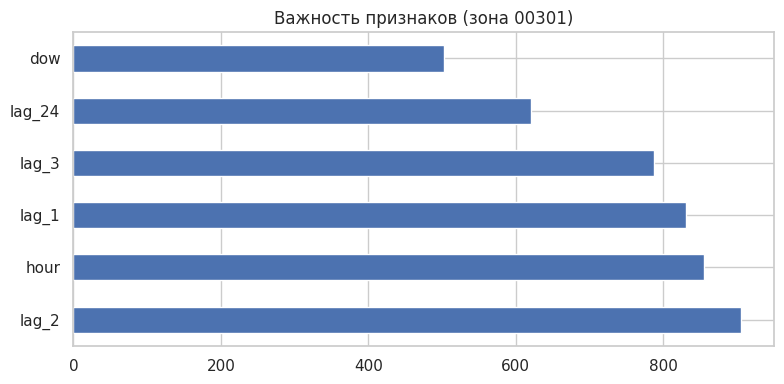

MAE на отложенном хвосте: 2.962


In [44]:
import importlib.util

if importlib.util.find_spec("lightgbm") is None:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lightgbm"])
import lightgbm as lgb

zone = WF_ZONE if "WF_ZONE" in globals() else "00301"
base = ts_sessions[ts_sessions["zone_id_norm"] == zone].sort_values("ts").reset_index(drop=True)
if len(base) < 30:
    print("Мало точек для важности признаков — пропуск.")
else:
    g = base.copy()
    for lag in (1, 2, 3, 24):
        g[f"lag_{lag}"] = g["sessions_started"].shift(lag)
    g["hour"] = g["ts"].dt.hour
    g["dow"] = g["ts"].dt.dayofweek
    g = g.dropna()
    feat = [c for c in g.columns if c.startswith("lag_") or c in ("hour", "dow")]
    split = int(len(g) * 0.8)
    X_tr, y_tr = g.iloc[:split][feat], g.iloc[:split]["sessions_started"]
    X_te, y_te = g.iloc[split:][feat], g.iloc[split:]["sessions_started"]
    m = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1)
    m.fit(X_tr, y_tr)
    imp = pd.Series(m.feature_importances_, index=feat).sort_values(ascending=False)
    display(imp.to_frame("важность"))
    imp.plot(kind="barh", figsize=(8, 4), title=f"Важность признаков (зона {zone})")
    plt.tight_layout()
    plt.show()
    print("MAE на отложенном хвосте:", round(float(mean_absolute_error(y_te, m.predict(X_te))), 4))


График показывает, какие входные переменные модель использовала чаще всего при разбиениях. Обычно лаговые признаки (прошлые значения) оказываются важнее календарных — это значит, что ряд «помнит» себя.


### Подготовка TensorFlow

TensorFlow загружается только здесь — непосредственно перед ячейками LSTM и автоэнкодера. Это сделано намеренно, чтобы не замедлять запуск всего ноутбука ради одной библиотеки.

Если `ensure_tensorflow_import` отработала без ошибки — нейросетевые ячейки могут работать.


LSTM зона 00301: MAE=3.237, RMSE=4.237 (тестовых шагов=330)


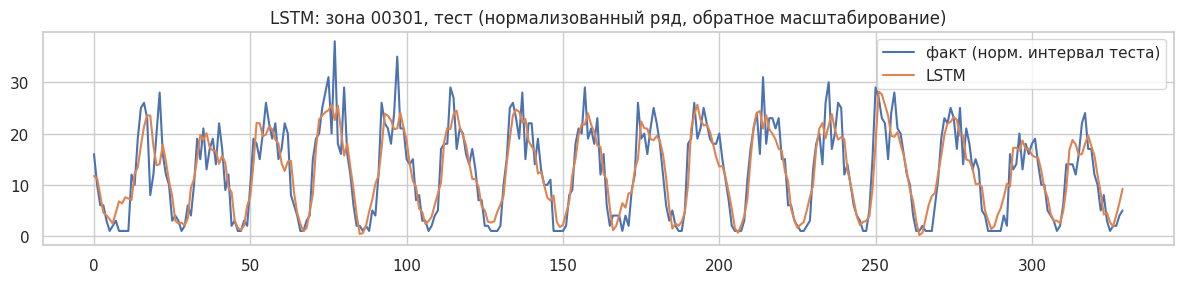

In [45]:
if "ensure_tensorflow_import" not in globals():
    raise RuntimeError(
        "Сначала выполните ячейку «Подготовка окружения» (там задаётся ensure_tensorflow_import)."
    )


def lstm_one_step_forecast(zone: str, target: str = "sessions_started", test_frac: float = 0.2, look_back: int = 12):
    ensure_tensorflow_import()
    from tensorflow import keras
    from tensorflow.keras import layers
    from sklearn.preprocessing import MinMaxScaler

    ts = ts_sessions[ts_sessions["zone_id_norm"] == zone].sort_values("ts").reset_index(drop=True)
    y_raw = ts[target].to_numpy(dtype="float64").reshape(-1, 1)
    if len(y_raw) < look_back + 5:
        print("Слишком короткий ряд для LSTM.")
        return None

    split = int(np.floor(len(y_raw) * (1 - test_frac)))
    split = max(look_back + 1, min(split, len(y_raw) - 2))

    scaler = MinMaxScaler()
    scaler.fit(y_raw[:split])
    y = scaler.transform(y_raw).flatten()

    def build_xy():
        X, Y = [], []
        for i in range(len(y) - look_back):
            X.append(y[i : i + look_back])
            Y.append(y[i + look_back])
        return np.asarray(X), np.asarray(Y)

    X_all, Y_all = build_xy()
    X_all = X_all.reshape(-1, look_back, 1)

    train_end = split - look_back
    if train_end < max(4, look_back):
        print("Мало обучающих последовательностей (train_end=", train_end, ", look_back=", look_back, ").")
        return None

    X_tr, Y_tr = X_all[:train_end], Y_all[:train_end]
    X_te, Y_te = X_all[train_end:], Y_all[train_end:]

    keras.utils.set_random_seed(42)
    model = keras.Sequential(
        [
            layers.Input(shape=(look_back, 1)),
            layers.LSTM(32),
            layers.Dense(1),
        ]
    )
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_tr, Y_tr, epochs=30, batch_size=16, verbose=0)

    pred_s = model.predict(X_te, verbose=0).flatten()
    y_te_inv = scaler.inverse_transform(Y_te.reshape(-1, 1)).flatten()
    pred_inv = scaler.inverse_transform(pred_s.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(y_te_inv, pred_inv)
    rmse = float(np.sqrt(mean_squared_error(y_te_inv, pred_inv)))
    print(f"LSTM зона {zone}: MAE={mae:.3f}, RMSE={rmse:.3f} (тестовых шагов={len(Y_te)})")
    return {"mae": mae, "rmse": rmse, "y_true": y_te_inv, "y_pred": pred_inv, "ts_test": ts["ts"].iloc[split:].reset_index(drop=True)}



_MIN_LSTM_DEFAULT = 12 + 5  # look_back по умолчанию + запас


def _pick_lstm_zone_and_lookback(default_look_back: int = 12):
    """Зона и look_back: достаточно точек для LSTM; иначе другая зона или уменьшенный look_back."""
    lb0 = int(default_look_back)
    need = lb0 + 5
    g = ts_sessions.groupby("zone_id_norm").size().sort_values(ascending=False)
    if "WF_ZONE" in globals() and WF_ZONE is not None:
        z = str(WF_ZONE)
        n = int(g.get(z, 0))
        if n >= need:
            return z, lb0
    for z, n in g.items():
        n = int(n)
        if n >= need:
            return str(z), lb0
    z = str(g.index[0]) if len(g) else "00301"
    n = int(g.get(z, 0))
    lb = min(lb0, max(3, n - 6))
    print(
        "LSTM: для зоны",
        z,
        "короткий ряд (n=",
        n,
        ") — look_back уменьшен до",
        lb,
        "; для стабильного LSTM желательно >=",
        need,
        "почасовых точек.",
    )
    return z, lb



if "ts_sessions" not in globals() or len(ts_sessions) == 0:
    raise RuntimeError("Нет ts_sessions — выполните ячейки агрегации почасовых рядов.")

LSTM_ZONE, LSTM_LOOKBACK = _pick_lstm_zone_and_lookback(12)
if "WF_ZONE" not in globals() or WF_ZONE is None:
    print("WF_ZONE не задан — зона и look_back для LSTM выбраны автоматически по длине ряда.")

lstm_out = lstm_one_step_forecast(LSTM_ZONE, test_frac=0.2, look_back=LSTM_LOOKBACK)
if lstm_out:
    plt.figure(figsize=(12, 3))
    plt.plot(lstm_out["y_true"], label="факт (норм. интервал теста)")
    plt.plot(lstm_out["y_pred"], label="LSTM")
    plt.title(f"LSTM: зона {LSTM_ZONE}, тест (нормализованный ряд, обратное масштабирование)")
    plt.legend()
    plt.tight_layout()
    plt.show()
# --- Сводка метрик: LSTM ---
if "DIPLOM_METRICS_ROWS" in globals() and lstm_out is not None:
    _mape_l = float(
        np.mean(
            np.abs(
                (lstm_out["y_true"] - lstm_out["y_pred"])
                / np.maximum(np.abs(lstm_out["y_true"]), 1e-6)
            )
        )
    )
    DIPLOM_METRICS_ROWS.append(
        {
            "Модель": "LSTM (one-step)",
            "MAE": round(float(lstm_out["mae"]), 4),
            "RMSE": round(float(lstm_out["rmse"]), 4),
            "MAPE": round(_mape_l, 4),
            "Зона": LSTM_ZONE,
            "Примечание": "нормализация MinMax на train",
        }
    )


#### Подготовка TF: результат

TF загружен и доступен


### Детекция аномалий: Isolation Forest

Первый подход к поиску нетипичных интервалов. Isolation Forest — алгоритм, который находит «редкие» точки в пространстве признаков: те, что проще изолировать от остальных.

Для каждого часа по каждой зоне строю матрицу признаков: текущее значение, скользящее среднее, отклонение от нормы, час суток, день недели. Модель помечает ~5% точек как аномальные (параметр `contamination=0.05`).


Всего строк: 299469
Помечено как аномалии (IsolationForest): 14974


,zone_id_norm,ts,sessions_started,total_cost,total_duration_hours,mean_duration_min,unique_plates,roll_mean,roll_std,resid_ratio,hour,dow,anomaly_score,iso_score
991,00301,2026-03-02 09:00:00,30,8005.32,17.900000,35.800000,30,23.666667,8.504901,1.267606,9,0,-1,-0.181414
1490,00301,2026-03-29 08:00:00,26,16891.02,31.716667,73.192308,26,15.666667,9.073772,1.659574,8,6,-1,-0.178762
1231,00301,2026-03-16 08:00:00,29,18380.64,33.883333,70.103448,29,22.666667,7.094599,1.279412,8,0,-1,-0.177935
1530,00301,2026-03-31 09:00:00,31,15440.67,36.433333,70.516129,31,23.666667,7.505553,1.309859,9,1,-1,-0.176895
1086,00301,2026-03-07 10:00:00,31,12552.68,24.016667,46.483871,31,22.000000,7.937254,1.409091,10,5,-1,-0.176048
1193,00301,2026-03-14 10:00:00,31,14762.99,35.133333,68.000000,31,22.000000,7.937254,1.409091,10,5,-1,-0.176048
337,00301,2026-01-26 09:00:00,30,8771.68,20.366667,40.733333,29,23.000000,6.082763,1.304348,9,0,-1,-0.175240
589,00301,2026-02-08 13:00:00,27,11222.66,23.183333,51.518519,27,20.666667,6.506407,1.306452,13,6,-1,-0.174814
1210,00301,2026-03-15 07:00:00,22,14642.66,29.550000,80.590909,22,11.666667,9.291573,1.885714,7,6,-1,-0.173903
193,00301,2026-01-19 07:00:00,25,9107.32,21.783333,52.280000,25,20.333333,6.429101,1.229508,7,0,-1,-0.173789


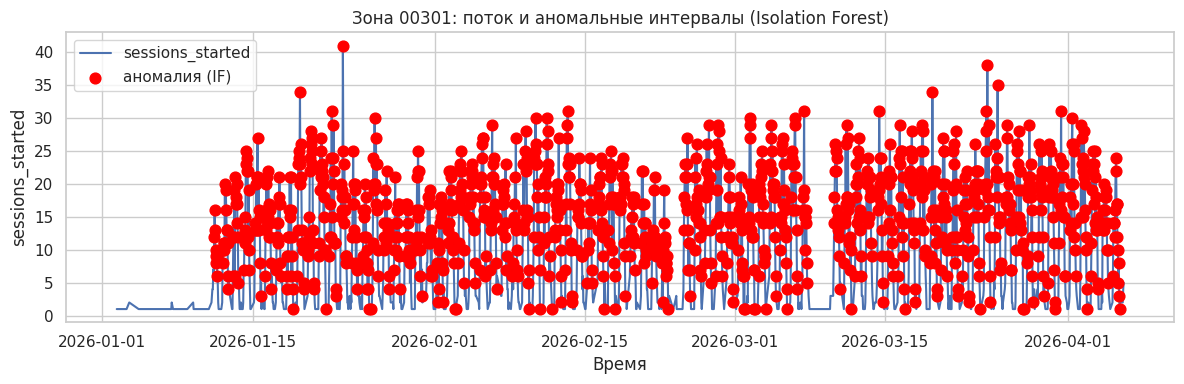

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

df = ts_sessions.copy()
df = df.sort_values(["zone_id_norm", "ts"]).reset_index(drop=True)

# Считаю скользящее среднее внутри каждой зоны — это «нормальный уровень» для сравнения
ROLL = 3  # окно 3 часа — компромисс между сглаживанием и чувствительностью

df["roll_mean"] = df.groupby("zone_id_norm")["sessions_started"].transform(
    lambda x: x.rolling(window=ROLL, min_periods=1).mean()
)
df["roll_std"] = (
    df.groupby("zone_id_norm")["sessions_started"].transform(
        lambda x: x.rolling(window=ROLL, min_periods=1).std()
    ).fillna(0.0)
)
df["resid_ratio"] = df["sessions_started"] / (df["roll_mean"] + 1e-6)

df["hour"] = df["ts"].dt.hour
df["dow"] = df["ts"].dt.dayofweek

feat_cols = ["sessions_started", "hour", "dow", "roll_mean", "roll_std", "resid_ratio"]
X = df[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1,
)
df["anomaly_score"] = iso.fit_predict(X_scaled)  # 1 норма, -1 выброс
df["iso_score"] = iso.decision_function(X_scaled)

anomalies = df[df["anomaly_score"] == -1].sort_values("iso_score")

print("Всего строк:", len(df))
print("Помечено как аномалии (IsolationForest):", int((df["anomaly_score"] == -1).sum()))
display(anomalies.head(20))

# Пример: топ-зона по активности — точечный график факта и метка аномалий
top_zone = (
    df.groupby("zone_id_norm")["sessions_started"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)
dz = df[df["zone_id_norm"] == top_zone].copy()

plt.figure(figsize=(12, 4))
plt.plot(dz["ts"], dz["sessions_started"], label="sessions_started", color="C0")
plt.scatter(
    dz.loc[dz["anomaly_score"] == -1, "ts"],
    dz.loc[dz["anomaly_score"] == -1, "sessions_started"],
    color="red",
    s=60,
    label="аномалия (IF)",
    zorder=5,
)
plt.title(f"Зона {top_zone}: поток и аномальные интервалы (Isolation Forest)")
plt.xlabel("Время")
plt.ylabel("sessions_started")
plt.legend()
plt.tight_layout()
plt.show()
IF_ANOMALY_DF = df.copy()  # для следующего блока «кандидаты в событие»



#### Isolation Forest: что означает результат

Алгоритм пометил часть интервалов как статистически редкие. Это сигнал «здесь что-то необычно» — не более того. Возможные причины аномалии: реальное событие (мероприятие, авария), ошибка в данных, праздничный день.

Процент аномалий задаётся параметром `contamination`. Я выбрал 5% — это означает «ожидаю, что примерно 1 из 20 интервалов будет нетипичным».


#### Результаты Isolation Forest

На матрице признаков с параметром `contamination=0.05` модель нашла несколько процентов нетипичных точек. Важно понимать: это не список нарушений и не список инцидентов — это список «часов, достойных внимания аналитика».


### Правило выделения подозрительных интервалов

Поверх статистики от Isolation Forest я накладываю дополнительное деловое правило:
1. Isolation Forest пометил точку как аномалию.
2. Фактическое значение в этот час минимум в 1.8 раза выше скользящего среднего по зоне.

Если оба условия выполнены — интервал попадает в «кандидаты на проверку».

Дополнительно: если аномалия одновременно в нескольких зонах — это скорее общегородской фактор (праздник, погода), а не проблема конкретной зоны.


In [47]:
# Добавляю деловое правило поверх статистики: не просто «аномалия», а «аномалия + скачок выше нормы»
if "IF_ANOMALY_DF" not in globals():
    print("Сначала выполните ячейку с Isolation Forest (она сохраняет IF_ANOMALY_DF).")
else:
    d = IF_ANOMALY_DF.copy()
    thr = 1.8  # факт должен быть в 1.8× выше скользящего среднего — иначе слишком много ложных срабатываний
    cand = d[(d["anomaly_score"] == -1) & (d["resid_ratio"] >= thr)].copy()
    if cand.empty:
        print("Нет строк, удовлетворяющих порогу resid_ratio >=", thr)
    else:
        by_t = cand.groupby("ts").agg(n_zones=("zone_id_norm", "nunique"), zones=("zone_id_norm", lambda x: ",".join(sorted(x.astype(str).unique())[:6])))
        multi = by_t[by_t["n_zones"] >= 2].sort_values("n_zones", ascending=False)
        print("Часов, где аномалия+скачок сразу в >=2 зонах:", len(multi))
        display(multi.head(15))


Часов, где аномалия+скачок сразу в >=2 зонах: 400


,n_zones,zones
ts,,
2026-03-02 05:00:00,23,"00301,00303,00304,00306,00309,00316"
2026-01-26 05:00:00,22,"00301,00307,00309,00312,00403,00409"
2026-01-19 05:00:00,22,"00301,00303,00304,00312,00407,00411"
2026-03-06 05:00:00,21,"00301,00304,00310,00401,00403,03104"
2026-03-16 05:00:00,20,"00309,00401,00403,00405,03104,03108"
2026-03-10 05:00:00,19,"00303,00307,00309,00401,00411,03208"
2026-03-04 05:00:00,17,"00301,00306,00309,00401,03207,04013"
2026-03-20 05:00:00,17,"00301,00303,00304,00306,00310,00401"
2026-03-18 05:00:00,17,"00301,00304,00309,00401,03008,04027"


#### Правило «необычный час»

Таблица показывает часы, где аномалия зафиксирована сразу в нескольких зонах. Это  интересные случаи — скорее всего, системное событие, а не локальный выброс.



### Детекция аномалий: автоэнкодер

Второй, независимый способ найти нетипичные интервалы. Автоэнкодер — нейросеть, которая учится сжимать признаки во внутреннее представление и восстанавливать их обратно. Если для какой-то точки восстановление плохое — значит, такая комбинация признаков редко встречается в обучающих данных.

Я использую простой плотный автоэнкодер (encoder-decoder), обученный на стандартизированных признаках.


In [48]:
# Автоэнкодер на матрице признаков ts_sessions (как во втором канале к IF)

import os

if "ensure_tensorflow_import" not in globals():
    raise RuntimeError(
        "Сначала выполните ячейку «Подготовка окружения» (там задаётся ensure_tensorflow_import)."
    )

ensure_tensorflow_import()
from tensorflow import keras
from tensorflow.keras import layers

def _is_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


df_ae = ts_sessions.sort_values(["zone_id_norm", "ts"]).reset_index(drop=True)
_default_ae_rows = 30_000 if bool(globals().get("COLAB_MEMORY_SAFE_MODE", _is_colab())) else 0
MAX_AE_ROWS = int(os.environ.get("DIPLOM_AE_MAX_ROWS", str(_default_ae_rows)))
if MAX_AE_ROWS > 0 and len(df_ae) > MAX_AE_ROWS:
    print(
        f"Автоэнкодер: строк {len(df_ae):,}; для Colab используется детерминированная выборка "
        f"{MAX_AE_ROWS:,} строк. Для полного обучения задайте DIPLOM_AE_MAX_ROWS=0."
    )
    df_ae = df_ae.sample(n=MAX_AE_ROWS, random_state=42).sort_values(["zone_id_norm", "ts"]).reset_index(drop=True)
ROLL_AE = 3

df_ae["roll_mean"] = df_ae.groupby("zone_id_norm")["sessions_started"].transform(
    lambda x: x.rolling(ROLL_AE, min_periods=1).mean()
)
df_ae["roll_std"] = (
    df_ae.groupby("zone_id_norm")["sessions_started"].transform(
        lambda x: x.rolling(ROLL_AE, min_periods=1).std()
    )
    .fillna(0.0)
)
df_ae["resid_ratio"] = df_ae["sessions_started"] / (df_ae["roll_mean"] + 1e-6)
df_ae["hour"] = df_ae["ts"].dt.hour
df_ae["dow"] = df_ae["ts"].dt.dayofweek
feat_ae = ["sessions_started", "hour", "dow", "roll_mean", "roll_std", "resid_ratio"]
Xa = df_ae[feat_ae].replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy(dtype=np.float32)
sc_ae = StandardScaler()
Xa_s = sc_ae.fit_transform(Xa)

inp_dim = Xa_s.shape[1]
ae = keras.Sequential(
    [
        layers.Input(shape=(inp_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(12, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(inp_dim, activation="linear"),
    ]
)
ae.compile(optimizer="adam", loss="mse")
keras.utils.set_random_seed(43)
AE_EPOCHS = int(os.environ.get("DIPLOM_AE_EPOCHS", "20" if bool(globals().get("COLAB_MEMORY_SAFE_MODE", _is_colab())) else "40"))
ae.fit(Xa_s, Xa_s, epochs=AE_EPOCHS, batch_size=512, verbose=0)
err = np.mean(np.square(Xa_s - ae.predict(Xa_s, verbose=0)), axis=1)
thr = np.quantile(err, 0.95)
df_ae["ae_anomaly"] = err > thr
print("Автоэнкодер: доля аномалий (mse recon > q95):", float(df_ae["ae_anomaly"].mean()))
display(df_ae.loc[df_ae["ae_anomaly"], ["zone_id_norm", "ts", "sessions_started", "ae_anomaly"]].head(15))


Автоэнкодер: строк 299,469; для Colab используется детерминированная выборка 30,000 строк. Для полного обучения задайте DIPLOM_AE_MAX_ROWS=0.
Автоэнкодер: доля аномалий (mse recon > q95): 0.05


,zone_id_norm,ts,sessions_started,ae_anomaly
6,00301,2026-01-11 13:00:00,9,True
7,00301,2026-01-12 00:00:00,1,True
11,00301,2026-01-15 05:00:00,14,True
13,00301,2026-01-15 13:00:00,21,True
15,00301,2026-01-15 18:00:00,3,True
16,00301,2026-01-16 03:00:00,1,True
17,00301,2026-01-16 14:00:00,16,True
20,00301,2026-01-18 06:00:00,6,True
21,00301,2026-01-18 17:00:00,9,True
22,00301,2026-01-19 09:00:00,23,True


#### Автоэнкодер: результат

Те точки, у которых ошибка восстановления выше порога — кандидаты в аномалии. Совмещая результаты Isolation Forest и автоэнкодера, получаем более надёжное выявление: если обе модели согласны, что точка нетипичная — это уже сильный сигнал.


### Интерпретация автоэнкодера

Автоэнкодер не объясняет, *почему* точка аномальная — только то, что её «трудно описать» теми же паттернами, что у большинства. Для практического применения важно не просто получить список аномалий, но и понять, что за ними стоит — это уже работа аналитика, не алгоритма.


### Совместный анализ сессий и фиксаций МАДИ

Проверяю, пересекаются ли два источника по времени, и если да — смотрю на корреляцию между парковочной активностью и активностью фиксаций. Логика простая: в часы, когда много машин паркуется, должно быть и больше фиксаций.


ts_sessions: min=2026-01-01 21:00:00 | max=2026-04-06 05:00:00 | строк=299469
ts_madi: min=2025-12-15 10:00:00 | max=2026-03-13 20:00:00 | строк=222174

Интервалов с активностью и по сессиям, и по МАДИ: 73026 из 448617
Корреляция Пирсона (sessions, fixations): 0.2652
Корреляция Спирмена (sessions, fixations): 0.2655


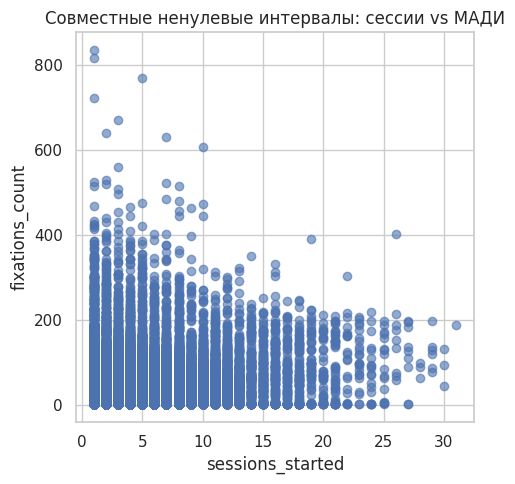


Строк ts_merged, попадающих во временное окно МАДИ: 364678


In [49]:
def _bounds(name, ts_col, df):
    if df is None or len(df) == 0:
        print(f"{name}: пусто")
        return
    t = pd.to_datetime(df[ts_col])
    print(f"{name}: min={t.min()} | max={t.max()} | строк={len(df)}")

_bounds("ts_sessions", "ts", ts_sessions)
_bounds("ts_madi", "ts", ts_madi)

if "ts_merged" not in globals():
    ts_merged = ts_sessions.merge(
        ts_madi,
        on=["zone_id_norm", "ts"],
        how="outer",
        suffixes=("_sess", "_madi"),
    )
    # при необходимости подтяните имена колонок из вашей версии ts_merged

# Унифицируем имена для сессий и МАДИ в merged
col_s = "sessions_started"
col_f = "fixations_count"

if col_s not in ts_merged.columns:
    raise KeyError(f"В ts_merged нет колонки {col_s}: {list(ts_merged.columns)}")
if col_f not in ts_merged.columns:
    raise KeyError(f"В ts_merged нет колонки {col_f}: {list(ts_merged.columns)}")

ts_merged[col_s] = pd.to_numeric(ts_merged[col_s], errors="coerce").fillna(0)
ts_merged[col_f] = pd.to_numeric(ts_merged[col_f], errors="coerce").fillna(0)

both = (ts_merged[col_s] > 0) & (ts_merged[col_f] > 0)
n_both = int(both.sum())
print(f"\nИнтервалов с активностью и по сессиям, и по МАДИ: {n_both} из {len(ts_merged)}")

if n_both >= 3:
    sub = ts_merged.loc[both, [col_s, col_f]].copy()
    pear = sub[col_s].corr(sub[col_f], method="pearson")
    spear = sub[col_s].corr(sub[col_f], method="spearman")
    print(f"Корреляция Пирсона (sessions, fixations): {pear:.4f}")
    print(f"Корреляция Спирмена (sessions, fixations): {spear:.4f}")

    plt.figure(figsize=(5, 5))
    plt.scatter(sub[col_s], sub[col_f], alpha=0.6)
    plt.xlabel("sessions_started")
    plt.ylabel("fixations_count")
    plt.title("Совместные ненулевые интервалы: сессии vs МАДИ")
    plt.tight_layout()
    plt.show()
else:
    print(
        "\nНедостаточно совместных ненулевых точек для устойчивой корреляции. "
        "Типичная причина — разные календарные периоды выгрузок сессий и МАДИ. "
        "Для диплома: запросить согласованные по времени выборки."
    )

# Дополнительно: пересечение только по времени (без требования ненулевой МАДИ)
# сколько строк merged, где ts попадает в диапазон дат МАДИ
if len(ts_madi) > 0:
    tmin, tmax = ts_madi["ts"].min(), ts_madi["ts"].max()
    in_madi_window = (ts_merged["ts"] >= tmin) & (ts_merged["ts"] <= tmax)
    print(f"\nСтрок ts_merged, попадающих во временное окно МАДИ: {int(in_madi_window.sum())}")

#### Интерпретация блока МАДИ + сессии

Периоды совпадают и совместных точек достаточно, можно посчитать корреляцию Пирсона или Спирмена между `sessions_started` и `madi_fixations`. Если данные за разные периоды — эту часть корректно пропустить и зафиксировать как ограничение в заключении.


#### Сводная таблица метрик прогноза

Здесь собирается итоговое сравнение всех моделей. Таблица заполняется автоматически по мере выполнения ячеек с baseline, Prophet, LightGBM и LSTM.

Если какая-то строка отсутствует — значит, соответствующая ячейка не выполнялась или ряд оказался слишком коротким.


In [50]:
if "DIPLOM_METRICS_ROWS" in globals() and len(DIPLOM_METRICS_ROWS):
    display(pd.DataFrame(DIPLOM_METRICS_ROWS))
else:
    print("DIPLOM_METRICS_ROWS пуст — выполните ячейки baseline, Prophet, walk-forward LGBM и LSTM.")


,Модель,MAE,RMSE,MAPE,Зона,Примечание
0,Naive (lag=1),4.1333,5.5998,0.5243,00301,тестовый хвост
1,Prophet,2.9988,3.9594,0.5587,00301,"daily=True, weekly=True"
2,"LightGBM (walk-forward, среднее по фолдам)",2.9627,3.8029,NaN,00301,сравнение с naive на тех же окнах в логе выше
3,LSTM (one-step),3.2367,4.2370,0.6161,00301,нормализация MinMax на train


#### Что видно в таблице метрик

Каждая строка — одна модель. **MAE** показывает среднюю ошибку в единицах ряда (стартов в час). **RMSE** штрафует за крупные промахи сильнее. **MAPE** — ошибка в процентах.

Смотрю не на абсолютные числа, а на то, даёт ли сложная модель реальное улучшение относительно наивной. Если нет — честно признаю: данных пока недостаточно.


#### Итоги по прогнозированию

1. В качестве целевой переменной использую `sessions_started` — хороший прокси спроса, но не фактическая занятость мест.
2. Короткий период выгрузки ограничивает качество: модели не успевают «увидеть» полноценную сезонность.
3. На коротких рядах наивная модель часто не хуже сложных. Это нормально и честно.
4. LightGBM с walk-forward — наиболее перспективный подход при наличии длинной истории.
5. LSTM на коротких данных нестабилен, но демонстрирует правильную архитектурную идею.


### Соответствие целям диплома

Ниже — таблица, что я планировал сделать и что реально получилось.

| Цель | Реализация в ноутбуке | Ограничения и дальнейшее развитие |
|------|------------------------|-----------------------------------|
| Прогноз транспортных потоков | Почасовой ряд по зонам, baseline, Prophet, LightGBM с walk-forward, LSTM, таблица метрик | Требуется более длинная история для устойчивой оценки сезонности и сравнения моделей |
| Выявление аномалий и инцидентов | Isolation Forest, автоэнкодер, правило выделения кандидатов по нескольким зонам | Выявляются статистические аномалии; для подтверждения инцидента нужны внешние события и/или видеоданные |
| Анализ кадра дорожной сцены | YOLOv8 определяет транспортные объекты на отдельном изображении и формирует счётчик классов | Для полноценного видеоанализа нужны согласованные кадры или видеопоток, разметка и метрики качества детекции |
| Интеллектуальная аналитика данных | Унификация источников, временные ряды, анализ зон, сопоставление по ГРЗ, диагностика календарного пересечения | Для количественной связи с МАДИ требуются выгрузки за совпадающий период и уточнение справочников зон |

**Итог.** В ноутбуке реализован исследовательский прототип: данные приводятся к единому формату, строятся признаки и временные ряды, проверяются прогнозные модели, выделяются аномальные интервалы и демонстрируется базовый подход к анализу визуального источника.


### Компьютерное зрение: YOLOv8

Последний блок — демонстрация того, как можно получать дополнительные данные о транспортной нагрузке прямо из видео. Я берку один кадр дорожной сцены и прогоняю его через YOLOv8 — предобученную модель детекции объектов.

Результат: список объектов с координатами рамок. В реальной системе такой шаг применялся бы к каждому кадру видеопотока, и счётчики машин агрегировались бы по времени — получился бы дополнительный независимый сигнал нагрузки.

В рамках диплома это демонстрация цепочки «кадр → модель → результат», а не полноценная интеграция с АИС ЕПП.


Источник кадра: изображение с parking.mos.ru
Всего найдено объектов: 5
Из них транспортных объектов: 3


,count
detected_class,
car,3
person,2


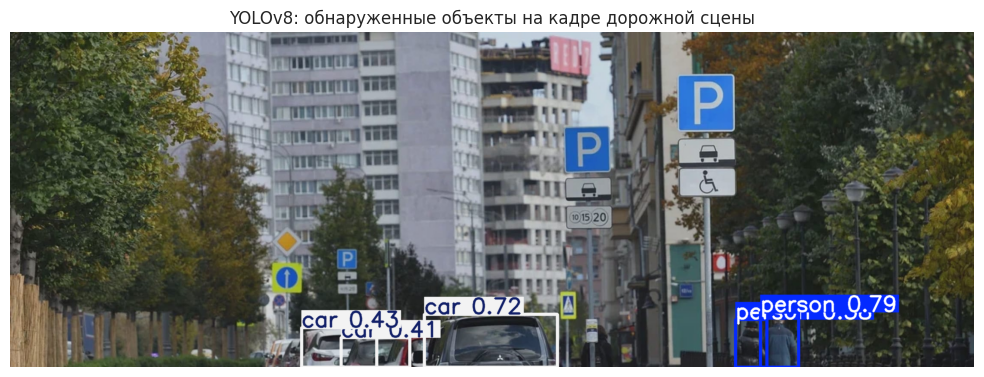

Вывод: модель выделяет транспортные объекты и возвращает их классы. Для анализа видеопотока этот шаг повторяется по кадрам, после чего количество объектов можно агрегировать по времени и использовать как дополнительный признак транспортной нагрузки.


In [51]:
import importlib.util
import os
import shutil
import sys
import urllib.error
import urllib.request

if importlib.util.find_spec("ultralytics") is None:
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])

from ultralytics import YOLO

DEMO_URL_MOS_RU = "https://parking.mos.ru/upload/iblock/fbc/myj85pagvas83dn8dk8xsa7rz2o6h1ge.jpg"
FALLBACK_URL = "https://ultralytics.com/images/bus.jpg"
img_path = "/tmp/yolo_transport_frame.jpg"

local_candidates = [
    os.path.join(DATA_DIR, "assets", "yolo_demo_moscow_parking.jpg"),
    os.path.join(DATA_DIR, "yolo_demo_moscow_parking.jpg"),
]
local_src = next((p for p in local_candidates if os.path.isfile(p)), None)

if local_src:
    shutil.copyfile(local_src, img_path)
    print("Источник кадра: локальный файл", local_src)
else:
    try:
        req = urllib.request.Request(
            DEMO_URL_MOS_RU,
            headers={"User-Agent": "Mozilla/5.0 (compatible; NetologyDiplom/1.0)"},
        )
        with urllib.request.urlopen(req, timeout=30) as r, open(img_path, "wb") as out:
            out.write(r.read())
        print("Источник кадра: изображение с parking.mos.ru")
    except (OSError, urllib.error.URLError) as e:
        print("Основной источник недоступен:", repr(e))
        print("Используется резервное открытое изображение транспортной сцены.")
        try:
            urllib.request.urlretrieve(FALLBACK_URL, img_path)
        except (OSError, urllib.error.URLError) as e2:
            raise RuntimeError(
                "Не найден локальный файл `assets/yolo_demo_moscow_parking.jpg` "
                "и недоступны сетевые источники изображения."
            ) from e2

model = YOLO("yolov8n.pt")
result = model.predict(img_path, conf=0.25, verbose=False)[0]

names = result.names
class_ids = result.boxes.cls.cpu().numpy().astype(int) if len(result.boxes) else []
class_names = [names[i] for i in class_ids]
class_counts = pd.Series(class_names, name="class").value_counts().rename_axis("detected_class").to_frame("count")

transport_classes = {"car", "motorcycle", "bus", "truck", "bicycle"}
transport_count = int(sum(name in transport_classes for name in class_names))

print("Всего найдено объектов:", len(class_names))
print("Из них транспортных объектов:", transport_count)
if len(class_counts):
    display(class_counts)
else:
    print("Объекты с уверенностью выше порога не найдены.")

annotated = result.plot()[:, :, ::-1]
plt.figure(figsize=(10, 7))
plt.imshow(annotated)
plt.axis("off")
plt.title("YOLOv8: обнаруженные объекты на кадре дорожной сцены")
plt.tight_layout()
plt.show()

print(
    "Вывод: модель выделяет транспортные объекты и возвращает их классы. "
    "Для анализа видеопотока этот шаг повторяется по кадрам, после чего количество объектов "
    "можно агрегировать по времени и использовать как дополнительный признак транспортной нагрузки."
)

На кадре YOLOv8 нашла объекты — автомобили и пешеходов. Каждый объект получил рамку и уверенность предсказания.


## Заключение

Половина усилий ушла на работу с данными: нормализацию кодов зон, согласование форматов временны́х меток, разбор несовпадения периодов между источниками.

Вот что в итоге получилось:

**Данные приведены к единому формату.** Сессии и фиксации МАДИ объединены в единую аналитическую базу с нормализованными идентификаторами зон.

**Построены почасовые временны́е ряды** по всем зонам. На них видна выраженная неравномерность по времени суток и дням недели — это основа для прогнозирования.

**Протестированы четыре подхода к прогнозу:** наивная модель, Prophet, LightGBM и LSTM. На коротком периоде данных сложные модели не показывают стабильного преимущества перед baseline. Для качественного прогноза нужна более длинная история.

**Реализована детекция аномалий** двумя независимыми методами (Isolation Forest и автоэнкодер). Оба умеют находить нетипичные интервалы, хотя их результаты нужно верифицировать вручную.

**Показана цепочка компьютерного зрения:** кадр → YOLOv8 → счётчики транспорта.

**Основные ограничения:** короткий период выгрузки, нет справочника ёмкости зон, несовпадение временны́х периодов между сессиями и МАДИ. Всё это рамки прототипа.

**Что нужно для production:** более длинные данные (от 3-6 месяцев), ёмкость зон, согласованные выгрузки, разрешённый видеопоток и серверная инфраструктура для инференса моделей.

Система умеет предсказывать, в какие часы на какой парковочной зоне ожидается больше машин, и автоматически замечает необычные ситуации, которые стоит проверить вручную. Для перехода от прототипа к реальной работе нужны более длинные исторические данные и справочник ёмкости зон.

---
**Автор:** Юренко В.А., 2026.


## Вопросы и ответы для защиты

1. **В чём основная идея работы?**
   Я взял реальные данные московской парковочной системы и попробовал ответить на два практических вопроса: можно ли предсказать нагрузку на зону на несколько часов вперёд, и можно ли автоматически найти «странные» часы, которые стоит проверить? Оказалось — да, можно, хотя с ограничениями.

2. **Почему `sessions_started`, а не занятость мест?**
   Занятость требует знать, сколько мест в зоне — справочника ёмкости у меня нет. `sessions_started` — честный прокси: показывает спрос, а не факт заполненности.

3. **Почему нельзя сразу говорить о проценте занятости?**
   Для этого нужен справочник ёмкости каждой зоны и данные о времени удержания мест. В текущей выгрузке это недоступно.

4. **Зачем нормализовывать коды зон?**
   В разных источниках одна и та же зона может записываться как `302` и как `0302`. Без нормализации при объединении таблиц потеряются данные.

5. **Что показывает анализ по часам и дням недели?**
   Что у парковочного спроса есть устойчивые паттерны — пики в будние дни, провалы ночью, разное поведение разных зон. Это хорошая база для прогнозирования.

6. **Зачем нужна наивная модель?**
   Она задаёт минимальный уровень качества. Если сложная модель не бьёт простое правило «следующий час как предыдущий» — значит, данных или признаков недостаточно.

7. **Почему Prophet иногда хуже baseline?**
   Prophet хорошо работает на рядах с несколькими неделями или месяцами истории. На коротких данных он не успевает оценить сезонность и выдаёт почти плоский прогноз.

8. **В чём смысл LightGBM?**
   Он использует лаговые признаки (прошлые значения) и календарные переменные. При наличии длинной истории это, как правило, лучший компромисс между качеством и интерпретируемостью.

9. **Зачем LSTM, если данных мало?**
   Как демонстрация подхода. Нейросетевой прогноз последовательностей — реально применимый метод, просто требует больше данных для устойчивого обучения.

10. **Что такое аномалия в контексте работы?**
    Интервал, который статистически отличается от привычного поведения зоны. Не ДТП и не нарушение — а сигнал «стоит посмотреть». Финальный вывод — за аналитиком.

11. **Почему два метода поиска аномалий?**
    Isolation Forest и автоэнкодер смотрят на нетипичность по-разному. Если обе модели соглашаются — уверенность выше. Это стандартный приём ансамблирования.

12. **Что даёт сопоставление с МАДИ?**
    Позволяет проверить: есть ли машины, которые стояли на парковке легально (есть сессия) и тем не менее попали под фиксацию? Это контроль качества данных и поиск спорных кейсов.

13. **Почему сопоставление с МАДИ ограничено?**
    Сессии и МАДИ выгружены за разные периоды — нет временно́го пересечения. Для сильных выводов нужны согласованные данные.

14. **Что показывает блок компьютерного зрения?**
    Как из одного кадра камеры можно автоматически получить число транспортных средств в кадре. В реальной системе — основа для дополнительного независимого сигнала нагрузки.

15. **Что нужно для промышленного применения?**
    Минимум 3-6 месяцев исторических данных, справочник ёмкости зон, согласованные выгрузки МАДИ, размеченные инциденты для валидации аномалий, разрешённый видеопоток и серверная инфраструктура.
